In [1]:
# For data generation
import sys
# !{sys.executable} -m pip install matplotlib --upgrade
import shutil
import os
import numpy as np
from glob import glob
import re
import pandas as pd
import pickle
#random
from time import perf_counter

# sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV


#Plotting
import seaborn as sns
sns.set_style()
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['figure.dpi'] = 200

import warnings
# warnings.filterwarnings("ignore", category=np.DeprecationWarning) 


from tqdm.auto import tqdm
# from tqdm.notebook import tqdm_notebook as tqdm

In [2]:
with open(os.path.join(os.path.expanduser('~'),'DDCASPT2/drop.txt'),'r') as d:
    dropfeat = [i.replace('\n','') for i in d.readlines()]

In [3]:
# with open('test_ind.pickle', 'rb') as handle:
#     test_ind = pickle.load(handle)

# with open('train_ind.pickle', 'rb') as handle:
#     train_ind = pickle.load(handle)

with open('big_test_ind.pickle', 'rb') as handle:
    test_ind = pickle.load(handle)

with open('big_train_ind.pickle', 'rb') as handle:
    train_ind = pickle.load(handle)
# train_ind = train_ind[train_ind>=110]
# test_ind = test_ind[test_ind>=110]    
train_ind = list(map(float,train_ind))
test_ind = list(map(float,test_ind))
train_ind, test_ind = train_test_split(train_ind+test_ind,test_size=0.1, random_state=42)
print(len(train_ind),len(test_ind))    


273 31


In [4]:
len(train_ind+test_ind)

304

In [5]:
train = []
test = []



recover_train = []
recover_test = []

traincnt = 0
testcnt = 0

for i in sorted(glob('ANO-RCC-VDZP')):
    print(i)
    for j in glob(os.path.join(i,'ozone_*')):
        for k in train_ind:
            if f"{k:.2f}" in j:
                traindf = pd.read_csv(os.path.join(j,os.path.basename(j)+'_1.csv'),compression='zip',index_col=0)
                traindf = traindf[traindf['Pair_Energies'].abs()>=1e-5]
                train.append(traindf)
                recover_train.append((i,f"{k:.2f}",traincnt,len(traindf)))
                traincnt+=1
                
        for l in test_ind:
            if f"{l:.2f}" in j:
                testdf = pd.read_csv(os.path.join(j,os.path.basename(j)+'_1.csv'),compression='zip',index_col=0)
                testdf = testdf[testdf['Pair_Energies'].abs()>=1e-5]
                test.append(testdf)                    
                recover_test.append((i,f"{l:.2f}",testcnt,len(testdf)))
                testcnt+=1

ANO-RCC-VDZP


In [6]:
rename = {'h$_{qq}^{0}$':'h$_{q}$',
'$(F_{q})_{0}$':'$F_{q}$',
'$(F_{q}^{\\text{SCF}})_{0}$':'$F_{q}^{\\text{SCF}}$',
'$(\\eta_{q})_{0}$':'$\\eta_{q}$',
'$(\\omega_{q})_{0}$':'$\\omega_{q}$',
'$(\\eta_{s})_{0}$':'$\\eta_{s}$',
'h$_{ss}^{0}$':'h$_{s}$',
'$(F_{s}^{\\text{SCF}})_{0}$':'$F_{s}^{\\text{SCF}}$',
'$(F_{s})_{0}$':'$F_{s}$',
'$(\\omega_{s})_{0}$':'$\\omega_{s}$',
'$(\\langle ss \\vert ss \\rangle)_{0}$':"$\\langle ss \\vert ss \\rangle$",
'$(\\langle qq \\vert qq \\rangle)_{0}$':"$\langle qq \\vert qq \\rangle$",
'h$_{pp}^{0}$': '(h$_{p}$)$_{0}$',
'h$_{pp}^{1}$': '(h$_{p}$)$_{1}$',
'h$_{pp}^{2}$': '(h$_{p}$)$_{2}$',
'h$_{pp}^{3}$': '(h$_{p}$)$_{3}$',
'h$_{rr}^{0}$': '(h$_{r}$)$_{0}$',
'h$_{rr}^{1}$': '(h$_{r}$)$_{1}$',
'h$_{rr}^{2}$': '(h$_{r}$)$_{2}$',
'h$_{rr}^{3}$': '(h$_{r}$)$_{3}$',
'h$_{pq}^{0}$':'(h$_{pq}$)$_{0}$',
'h$_{pq}^{1}$':'(h$_{pq}$)$_{1}$',
'h$_{pq}^{2}$':'(h$_{pq}$)$_{2}$',
'h$_{pq}^{3}$':'(h$_{pq}$)$_{3}$',
'h$_{pr}^{0}$':'(h$_{pr}$)$_{0}$',
'h$_{pr}^{1}$':'(h$_{pr}$)$_{1}$',
'h$_{pr}^{2}$':'(h$_{pr}$)$_{2}$',
'h$_{pr}^{3}$':'(h$_{pr}$)$_{3}$',
'h$_{rs}^{0}$':'(h$_{rs}$)$_{0}$',
'h$_{rs}^{1}$':'(h$_{rs}$)$_{1}$',
'h$_{rs}^{2}$':'(h$_{rs}$)$_{2}$',
'h$_{rs}^{3}$':'(h$_{rs}$)$_{3}$',
'typ_0':'$type_0$',
'typ_1':'$type_1$',
'typ_2':'$type_2$',
'typ_3':'$type_3$'}

In [7]:
train_df = pd.concat(train).drop(columns=dropfeat, errors='ignore').rename(columns=rename)
test_df = pd.concat(test).drop(columns=dropfeat, errors='ignore').rename(columns=rename)

In [8]:
pd.concat([train_df,test_df])[[i for i in train_df.columns if i=='(h$_{rs}$)$_{0}$']].std()

(h$_{rs}$)$_{0}$    3.064532
dtype: float64

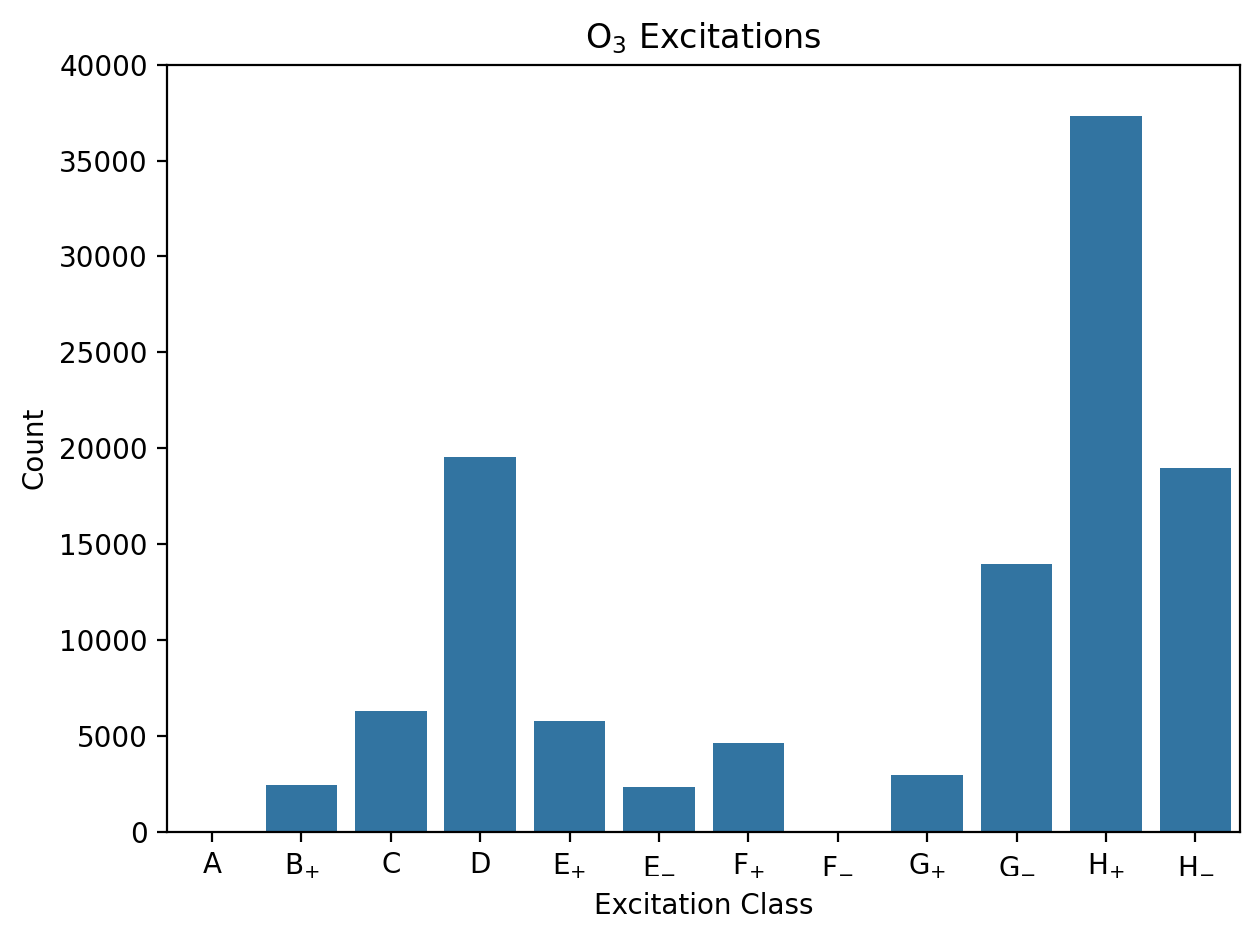

In [9]:
counttypes=pd.concat([pd.concat([train_df,test_df])[i].value_counts() for i in train_df.columns if 'typ' in i],axis=1).T.sum(axis=0).sort_index()
counttypes.index=[{1:"A", 2:"B$_{+}$", 3:"B$_{-}$", 4:"C", 5:"D", 6:"E$_{+}$", 7:"E$_{-}$", 8:"F$_{+}$", 9:"F$_{-}$", 10:"G$_{+}$", 11:"G$_{-}$", 12:"H$_{+}$", 13:"H$_{-}$"}[t] for t in counttypes.index+1]
sns.barplot(data=counttypes.reset_index(),x='index',y=0,color=sns.color_palette('Paired')[1])
plt.ylabel('Count')
plt.xlabel('Excitation Class')
plt.ylim(0,np.round(counttypes.max(), -4))
plt.title('O$_{3}$ Excitations')
plt.tight_layout()
plt.savefig('images/excitation_barplot_MB.png',dpi=300,bbox_inches='tight')
plt.show()

In [10]:
X_train = train_df.drop(columns=['Pair_Energies']).values
X_test = test_df.drop(columns=['Pair_Energies']).values

y_train = train_df['Pair_Energies'].values
y_test = test_df['Pair_Energies'].values

In [11]:
X_train.shape

(25657, 102)

In [12]:
scaler=MinMaxScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [13]:
from xgboost import XGBRegressor

kwargs = dict(pd.read_excel("ozone_MB_params.xlsx").values)
model=XGBRegressor(**kwargs)
model.fit(X_train,y_train)
y_pred_train=model.predict(X_train)
y_pred_test=model.predict(X_test)
print(f"R2: {r2_score(y_train,y_pred_train):.4f},{r2_score(y_test,y_pred_test):.4f}")
print(f"RMSE (mEh): {root_mean_squared_error(y_train,y_pred_train)*1e3:.4f},{root_mean_squared_error(y_test,y_pred_test)*1e3:.4f}")

# params = {'max_depth': [1, 10, 100],
#           'n_estimators': [100, 500, 1000],
#           'reg_lambda': [1e-6, 1e-3,1e-1],
#           'reg_alpha': [1e-6, 1e-3,1e-1]}

# model = XGBRegressor()
# grid = GridSearchCV(estimator=model, 
#                    param_grid=params,
#                    scoring='r2', 
#                    verbose=0,n_jobs=12).fit(X_train,y_train)


# model=grid.best_estimator_
# y_pred_train=model.predict(X_train)
# y_pred_test=model.predict(X_test)
# print(f"R2: {r2_score(y_train,y_pred_train):.4f},{r2_score(y_test,y_pred_test):.4f}")
# print(f"RMSE (mEh): {root_mean_squared_error(y_train,y_pred_train)*1e3:.4f},{root_mean_squared_error(y_test,y_pred_test)*1e3:.4f}")
# pd.DataFrame.from_dict(model.get_params(),orient='index').dropna().to_excel("ozone_MB_params.xlsx")

R2: 0.9996,0.9994
RMSE (mEh): 0.1680,0.2121


In [14]:
try:
    os.mkdir('images')
except:
    print('./images exist')

./images exist


In [15]:
y_train.min()*1e3,y_train.max()*1e3

(np.float64(-56.417208857000006), np.float64(16.215586674782003))

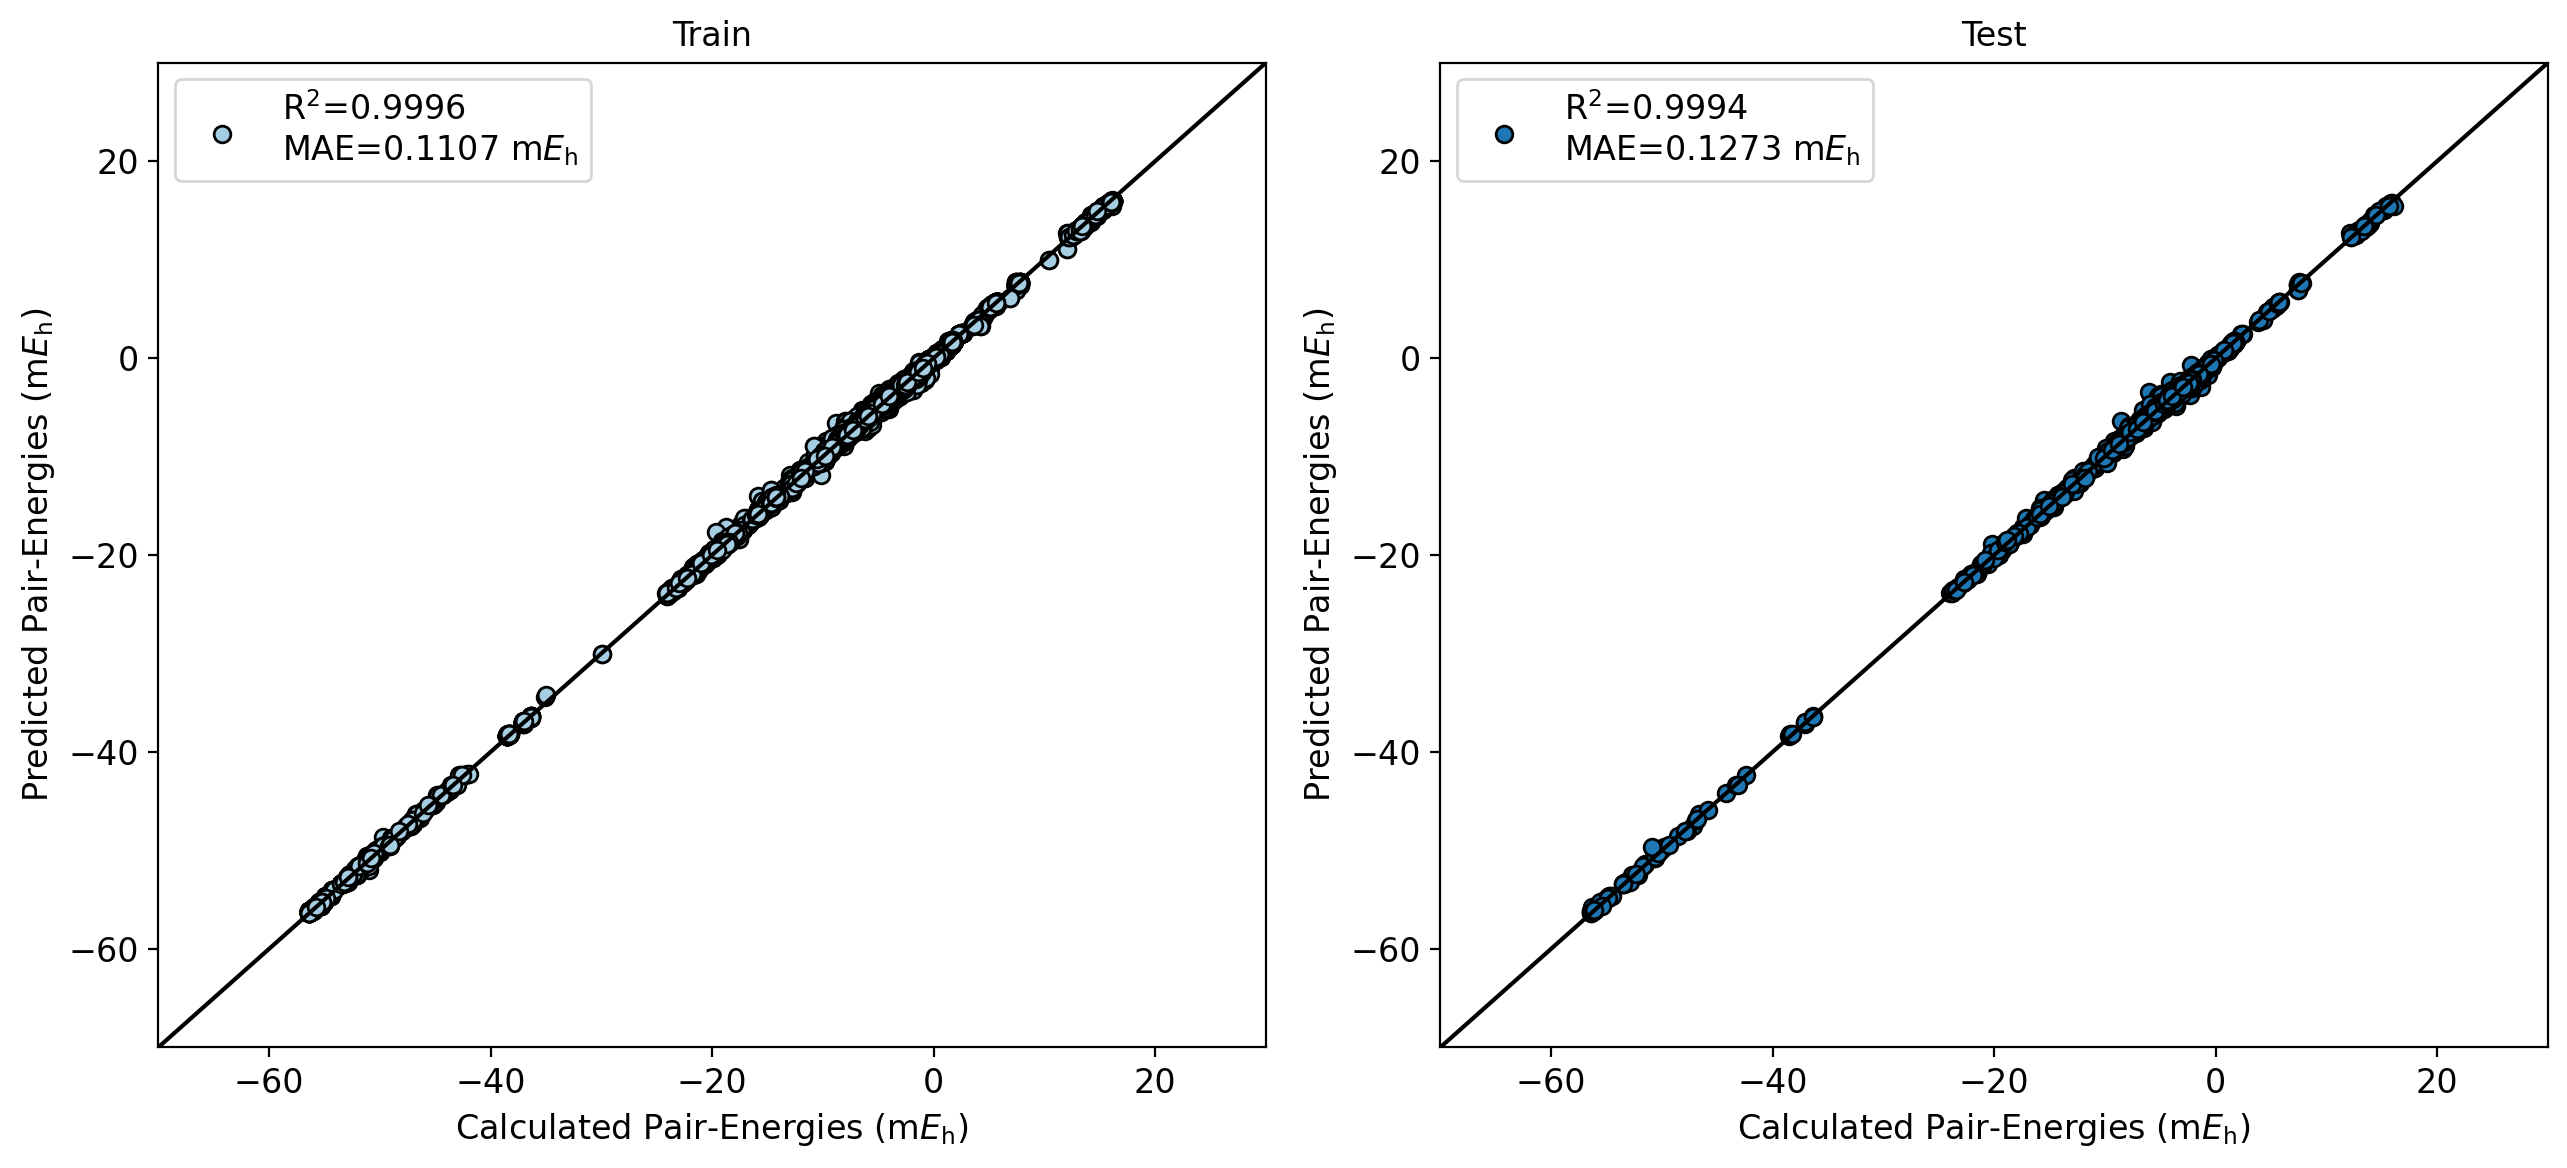

In [16]:
pal = sns.color_palette("Paired")
font=12
plt.rc('font', size=font)          # controls default text sizes
plt.rc('axes', titlesize=font)     # fontsize of the axes title
plt.rc('axes', labelsize=font)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=font)    # fontsize of the tick labels
plt.rc('ytick', labelsize=font)    # fontsize of the tick labels
plt.rc('legend', fontsize=font)    # legend fontsize
plt.rc('figure', titlesize=font)  # fontsize of the figure title
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,6))
scale=1e-1
minL,maxL = -70, 30
ax1.set_title('Train')
ax1.scatter(1e3*y_train,1e3*y_pred_train,label="R$^{2}$="+f'{r2_score(y_train,y_pred_train):.4f}\nMAE={1e3*mean_absolute_error(y_train,y_pred_train):.4f}'+" m$E_{\mathrm{h}}$",color=pal[0],edgecolors='k')
ax1.plot(np.arange(-100,100),np.arange(-100,100),'k-')
ax1.set_xlim(minL,maxL)
ax1.set_ylim(minL,maxL)
ax1.set_xlabel('Calculated Pair-Energies (m$E_{\mathrm{h}}$)')
ax1.set_ylabel('Predicted Pair-Energies (m$E_{\mathrm{h}}$)')
ax1.legend()


ax2.set_title('Test')
ax2.scatter(1e3*y_test,1e3*y_pred_test,label="R$^{2}$="+f'{r2_score(y_test,y_pred_test):.4f}\nMAE={1e3*mean_absolute_error(y_test,y_pred_test):.4f}'+" m$E_{\mathrm{h}}$",color=pal[1],edgecolors='k')
ax2.plot(np.arange(-100,100),np.arange(-100,100),'k-')
ax2.set_xlim(minL,maxL)
ax2.set_ylim(minL,maxL)
ax2.set_xlabel('Calculated Pair-Energies (m$E_{\mathrm{h}}$)')
ax2.set_ylabel('Predicted Pair-Energies (m$E_{\mathrm{h}}$)')
ax2.legend()

plt.tight_layout()
plt.savefig('images/ozone_MB_parity.png',dpi=300,bbox_inches='tight')
plt.show()

In [17]:
testcntrcvr = 0
recover_test_list = []
recover_test_E2 = []
for i,j,k,l in recover_test:
    init_test = testcntrcvr
    testcntrcvr+=l
    recover_test_list.append((i.split("_")[0],j,y_test[init_test:testcntrcvr],y_pred_test[init_test:testcntrcvr]))
    recover_test_E2.append((i.split("_")[0],j,np.sum(y_test[init_test:testcntrcvr]),np.sum(y_pred_test[init_test:testcntrcvr])))


traincntrcvr = 0
recover_train_list = []
recover_train_E2 = []
for i,j,k,l in recover_train:
    init_train = traincntrcvr
    traincntrcvr+=l
    recover_train_list.append((i.split("_")[0],j,y_train[init_train:traincntrcvr],y_pred_train[init_train:traincntrcvr]))
    recover_train_E2.append((i.split("_")[0],j,np.sum(y_train[init_train:traincntrcvr]),np.sum(y_pred_train[init_train:traincntrcvr])))

In [18]:
traincorrE2 = pd.DataFrame(recover_train_E2).rename(columns={0:"basis set",1:'Angle ($^{\circ}$)',2:'E$_{2}^{\text{Calculated}}$',3:'E$_{2}^{\text{Predicted}}$'})
#.astype({"basis set":str,'Angle ($^{\circ}$)':float,'E$_{2}^{\text{Calculated}}$':float,'E$_{2}^{\text{Predicted}}$':float})
testcorrE2 = pd.DataFrame(recover_test_E2).rename(columns={0:"basis set",1:'Angle ($^{\circ}$)',2:'E$_{2}^{\text{Calculated}}$',3:'E$_{2}^{\text{Predicted}}$'})
#.astype({"basis set":str,'Angle ($^{\circ}$)':float,'E$_{2}^{\text{Calculated}}$':float,'E$_{2}^{\text{Predicted}}$':float})


traincorrE2['CASPT2_E']=np.zeros(len(traincorrE2))
traincorrE2['CASSCF_E']=np.zeros(len(traincorrE2))
traincorrE2['E2']=np.zeros(len(traincorrE2))

traincorrE2.index = ["_".join((u,v)) for u,v in traincorrE2[["basis set",'Angle ($^{\circ}$)']].values]

for i in traincorrE2.index:
    hn, r = i.split('_')
    energy_df = pd.read_excel(f"{hn}/ozone_{r}/ozone_{r}_energies.xlsx",index_col=0)
    traincorrE2.loc[i,'CASPT2_E']=energy_df.loc['CASPT2_E'].values
    traincorrE2.loc[i,'CASSCF_E']=energy_df.loc['CASSCF_E'].values
    # traincorrE2.loc[i,'E2']=energy_df.loc['E2'].values

traincorrE2['E$_{\text{CASPT2}}^{\text{Predicted}}$'] = traincorrE2['CASSCF_E']+traincorrE2['E$_{2}^{\text{Predicted}}$']

traincorrE2.rename(columns = {'CASPT2_E':'E$_{\text{CASPT2}}^{\text{Calculated}}$','CASSCF_E':'E$_{\text{CASSCF}}^{\text{Calculated}}$'},inplace=True)


testcorrE2['CASPT2_E']=np.zeros(len(testcorrE2))
testcorrE2['CASSCF_E']=np.zeros(len(testcorrE2))
testcorrE2['E2']=np.zeros(len(testcorrE2))

testcorrE2.index = ["_".join((u,v)) for u,v in testcorrE2[["basis set",'Angle ($^{\circ}$)']].values]

for i in testcorrE2.index:
    hn, r = i.split('_')
    energy_df = pd.read_excel(f"{hn}/ozone_{r}/ozone_{r}_energies.xlsx",index_col=0)
    testcorrE2.loc[i,'CASPT2_E']=energy_df.loc['CASPT2_E'].values
    testcorrE2.loc[i,'CASSCF_E']=energy_df.loc['CASSCF_E'].values
    # testcorrE2.loc[i,'E2']=energy_df.loc['E2'].values

testcorrE2['E$_{\text{CASPT2}}^{\text{Predicted}}$'] = testcorrE2['CASSCF_E']+testcorrE2['E$_{2}^{\text{Predicted}}$']

testcorrE2.rename(columns = {'CASPT2_E':'E$_{\text{CASPT2}}^{\text{Calculated}}$','CASSCF_E':'E$_{\text{CASSCF}}^{\text{Calculated}}$'},inplace=True)

In [19]:
traincaspt2melt = traincorrE2.melt(id_vars=["basis set",'Angle ($^{\circ}$)'], value_vars=['E$_{\text{CASPT2}}^{\text{Calculated}}$','E$_{\text{CASPT2}}^{\text{Predicted}}$']).astype({'Angle ($^{\circ}$)':float,'value':float})
testcaspt2melt = testcorrE2.melt(id_vars=["basis set",'Angle ($^{\circ}$)'], value_vars=['E$_{\text{CASPT2}}^{\text{Calculated}}$','E$_{\text{CASPT2}}^{\text{Predicted}}$']).astype({'Angle ($^{\circ}$)':float,'value':float})

In [20]:
trueE2=pd.concat([traincorrE2,testcorrE2]).astype({'Angle ($^{\circ}$)':float,'E$_{\text{CASPT2}}^{\text{Calculated}}$':float})

In [21]:
mean_absolute_error(testcorrE2['E$_{\text{CASPT2}}^{\text{Calculated}}$'],testcorrE2['E$_{\text{CASPT2}}^{\text{Predicted}}$'])*1e3

np.float64(1.5144674645959582)

In [22]:
mean_absolute_error(traincorrE2['E$_{\text{CASPT2}}^{\text{Calculated}}$'],traincorrE2['E$_{\text{CASPT2}}^{\text{Predicted}}$'])*1e3

np.float64(1.1187288434583493)

In [23]:
pairedcp=sns.color_palette('Paired')

In [24]:
(traincorrE2['E$_{\text{CASPT2}}^{\text{Calculated}}$']-traincorrE2['E$_{\text{CASPT2}}^{\text{Predicted}}$']).abs().sort_values()

ANO-RCC-VDZP_168.00    0.000010
ANO-RCC-VDZP_179.75    0.000015
ANO-RCC-VDZP_169.75    0.000027
ANO-RCC-VDZP_168.25    0.000043
ANO-RCC-VDZP_138.25    0.000050
                         ...   
ANO-RCC-VDZP_106.25    0.003705
ANO-RCC-VDZP_145.00    0.003750
ANO-RCC-VDZP_109.25    0.004407
ANO-RCC-VDZP_180.00    0.004741
ANO-RCC-VDZP_106.00    0.006331
Length: 273, dtype: float64

In [25]:
allcorr = pd.concat([traincorrE2,testcorrE2])

In [26]:
allcorr[['E$_{2}^{\text{Predicted}}$','E$_{2}^{\text{Calculated}}$']].describe().loc[['min','max']]

,E$_{2}^{\text{Predicted}}$,E$_{2}^{\text{Calculated}}$
min,-0.544299,-0.541642
max,-0.521407,-0.528723


In [27]:
allcorr.min()

basis set                                  ANO-RCC-VDZP
Angle ($^{\circ}$)                               106.00
E$_{2}^{\text{Calculated}}$                   -0.541642
E$_{2}^{\text{Predicted}}$                    -0.544299
E$_{\text{CASPT2}}^{\text{Calculated}}$     -225.122966
E$_{\text{CASSCF}}^{\text{Calculated}}$     -224.590389
E2                                                  0.0
E$_{\text{CASPT2}}^{\text{Predicted}}$       -225.12596
dtype: object

0.8884673407868818
-225.1259601695137 -224.97334401080505
-225.2 -224.4


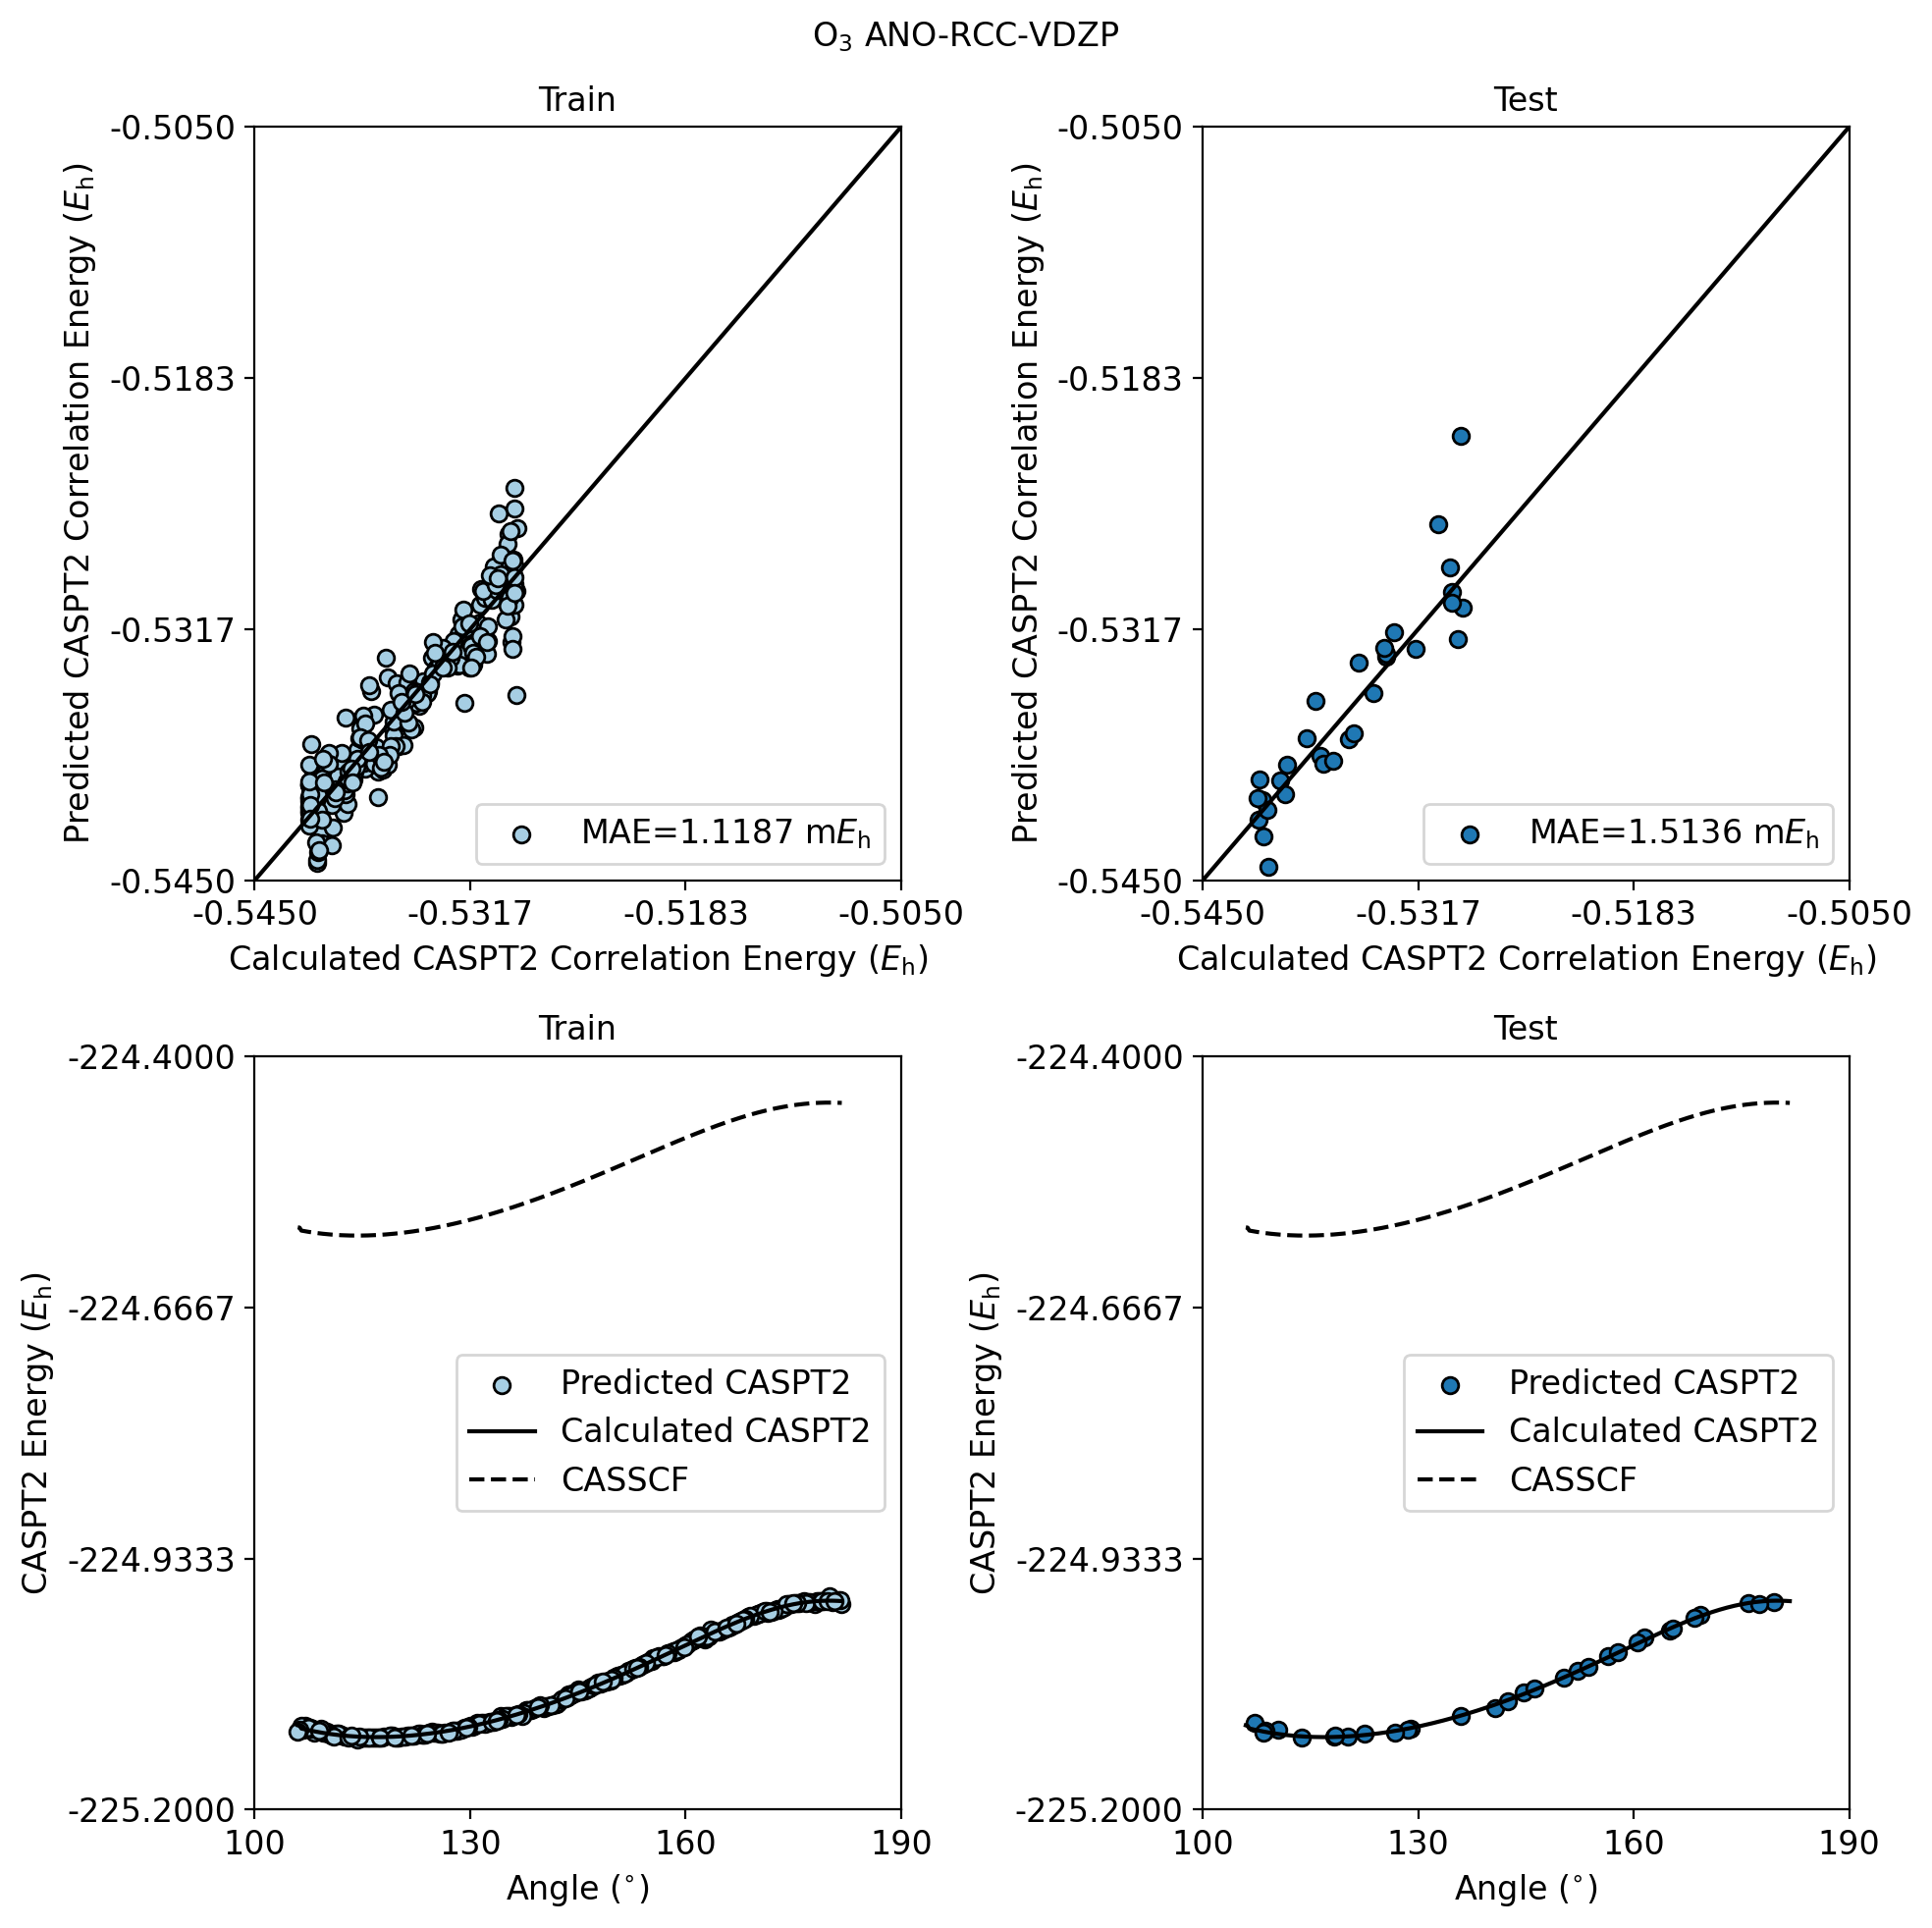

In [28]:
traincorrerr = {}

fig,((ax1,ax2),(ax3,ax4))=plt.subplots(2,2,figsize=(10,10),sharey=False)



pred_train,true_train = traincorrE2['E$_{2}^{\text{Predicted}}$'],traincorrE2['E$_{2}^{\text{Calculated}}$']
pred_test,true_test = testcorrE2['E$_{2}^{\text{Predicted}}$'],testcorrE2['E$_{2}^{\text{Calculated}}$']
testrad = testcorrE2['Angle ($^{\circ}$)']    
train_r2_corr = r2_score(true_train,pred_train)
test_r2_corr = r2_score(true_test,pred_test)
test_mae_corr = 1e3*mean_absolute_error(true_test,pred_test)
train_mae_corr = 1e3*mean_absolute_error(true_train,pred_train)
print(train_r2_corr)
traincorrerr = {"r2_train":train_r2_corr,"r2_test":test_r2_corr,"mae_train":train_mae_corr,"mae_test":test_mae_corr}
trainrad = traincorrE2['Angle ($^{\circ}$)']
# ax1.scatter(true_train,pred_train,label='R$^{2}$='+f'{train_r2_corr:.4f}\nMAE={train_mae_corr:.4f}'+" m$E_{\mathrm{h}}$",color=pairedcp[0],edgecolors='k')
ax1.scatter(true_train,pred_train,label=f'MAE={train_mae_corr:.4f}'+" m$E_{\mathrm{h}}$",color=pairedcp[0],edgecolors='k')

ax1.set_xlabel('Calculated CASPT2 Correlation Energy ($E_{\mathrm{h}}$)')
ax1.set_ylabel('Predicted CASPT2 Correlation Energy ($E_{\mathrm{h}}$)')
ax1.set_title('Train')
ax1.plot(np.arange(-1000,1000),np.arange(-1000,1000),'k')
ax1.legend(loc=4)


# ax2.scatter(true_test,pred_test,label='R$^{2}$='+f'{test_r2_corr:.4f}\nMAE={test_mae_corr:.4f}'+" m$E_{\mathrm{h}}$",color=pairedcp[1],edgecolors='k')
ax2.scatter(true_test,pred_test,label=f'MAE={test_mae_corr:.4f}'+" m$E_{\mathrm{h}}$",color=pairedcp[1],edgecolors='k')
# ax2.plot(true_test,true_test,'k')
ax2.plot(np.arange(-1000,1000),np.arange(-1000,1000),'k')
ax2.set_xlabel('Calculated CASPT2 Correlation Energy ($E_{\mathrm{h}}$)')
ax2.set_ylabel('Predicted CASPT2 Correlation Energy ($E_{\mathrm{h}}$)')

ax2.set_title('Test')    
ax2.legend(loc=4)
# MB
# bottom, top = -0.1035,-0.091
# vdzp
bottom, top = -0.545,-0.505
# vtzp 
# bottom, top = -0.705,-0.68
ax1.set_xlim(bottom, top)
ax1.set_ylim(bottom, top)
ax2.set_xlim(bottom, top)
ax2.set_ylim(bottom, top)
ax1.set_xticks(np.linspace(bottom,top,4),[f"{i:.4f}" for i in np.linspace(bottom,top,4)])
ax1.set_yticks(np.linspace(bottom,top,4),[f"{i:.4f}" for i in np.linspace(bottom,top,4)])    
# ax2.set_xlim(bottom,top)
ax2.set_xticks(np.linspace(bottom,top,4),[f"{i:.4f}" for i in np.linspace(bottom,top,4)])    
# ax2.set_ylim(bottom,top)
ax2.set_yticks(np.linspace(bottom,top,4),[f"{i:.4f}" for i in np.linspace(bottom,top,4)])    

pred_train,true_train = traincorrE2['E$_{\text{CASPT2}}^{\text{Predicted}}$'],traincorrE2['E$_{\text{CASPT2}}^{\text{Calculated}}$']
pred_test,true_test = testcorrE2['E$_{\text{CASPT2}}^{\text{Predicted}}$'],testcorrE2['E$_{\text{CASPT2}}^{\text{Calculated}}$']
testrad = testcorrE2['Angle ($^{\circ}$)']    


traincorrerr = {"r2_train":train_r2_corr,"r2_test":test_r2_corr,"mae_train":train_mae_corr,"mae_test":test_mae_corr}
trainrad = traincorrE2['Angle ($^{\circ}$)']
ax3.scatter(np.array(trainrad,dtype=float),pred_train,color=pairedcp[0],edgecolors='k',label='Predicted CASPT2')
ax3.plot(allcorr.sort_values(by='Angle ($^{\circ}$)')['Angle ($^{\circ}$)'].astype(float),allcorr.sort_values(by='Angle ($^{\circ}$)')['E$_{\text{CASPT2}}^{\text{Calculated}}$'].astype(float),'k',label='Calculated CASPT2')
ax3.plot(allcorr.sort_values(by='Angle ($^{\circ}$)')['Angle ($^{\\circ}$)'].astype(float),allcorr.sort_values(by='Angle ($^{\circ}$)')['E$_{\text{CASSCF}}^{\text{Calculated}}$'].astype(float),'k--',label='CASSCF')
ax3.set_xlabel('Angle ($^{\circ}$)')
ax3.set_ylabel('CASPT2 Energy ($E_{\mathrm{h}}$)')
ax3.set_title('Train')
ax3.legend()

ax4.scatter(np.array(testrad,dtype=float),pred_test,color=pairedcp[1],edgecolors='k',label='Predicted CASPT2')
ax4.plot(allcorr.sort_values(by='Angle ($^{\circ}$)')['Angle ($^{\circ}$)'].astype(float),allcorr.sort_values(by='Angle ($^{\circ}$)')['E$_{\text{CASPT2}}^{\text{Calculated}}$'].astype(float),'k',label='Calculated CASPT2')
ax4.plot(allcorr.sort_values(by='Angle ($^{\circ}$)')['Angle ($^{\\circ}$)'].astype(float),allcorr.sort_values(by='Angle ($^{\circ}$)')['E$_{\text{CASSCF}}^{\text{Calculated}}$'].astype(float),'k--',label='CASSCF')
ax4.set_xlabel('Angle ($^{\circ}$)')
ax4.set_ylabel('CASPT2 Energy ($E_{\mathrm{h}}$)')
ax4.set_title('Test') 
ax4.legend()

minpt2, maxpt2= pd.concat([pred_train,true_train,pred_test,true_test]).min(), pd.concat([pred_train,true_train,pred_test,true_test]).max()
print(minpt2, maxpt2)
pct=0.004
bufferbot, buffertop = minpt2*pct, maxpt2*pct



#mb
# bottom, top = -224.5, -224.1984 
#maxpt2-(buffertop) 

# vdzp: -224.40
bottom, top = -225.2, -224.4

# vtzp
# bottom, top = -225.4, -224.4
print(bottom, top)
ax3.set_ylim(bottom,top)
ax3.set_xlim(100,190)
ax3.set_yticks(np.linspace(bottom,top,4),[f"{i:.4f}" for i in np.linspace(bottom,top,4)]) 
ax3.set_xticks(np.linspace(100,190,4),[f"{i:.0f}" for i in np.linspace(100,190,4)]) 
ax4.set_ylim(bottom,top)
ax4.set_xlim(100,190)
ax4.set_yticks(np.linspace(bottom,top,4),[f"{i:.4f}" for i in np.linspace(bottom,top,4)]) 
ax4.set_xticks(np.linspace(100,190,4),[f"{i:.0f}" for i in np.linspace(100,190,4)]) 


fig.suptitle("O$_{3}$ ANO-RCC-VDZP")

plt.subplots_adjust(wspace=0.05)
plt.tight_layout()
plt.savefig(f'images/ozone_MBCASPT2.png',dpi=300,bbox_inches='tight')
plt.show()    

In [29]:
np.linspace(100,190,4)

array([100., 130., 160., 190.])

In [30]:
[f"{i:.4}" for i in np.linspace(bottom,top,4)]

['-225.2', '-224.9', '-224.7', '-224.4']

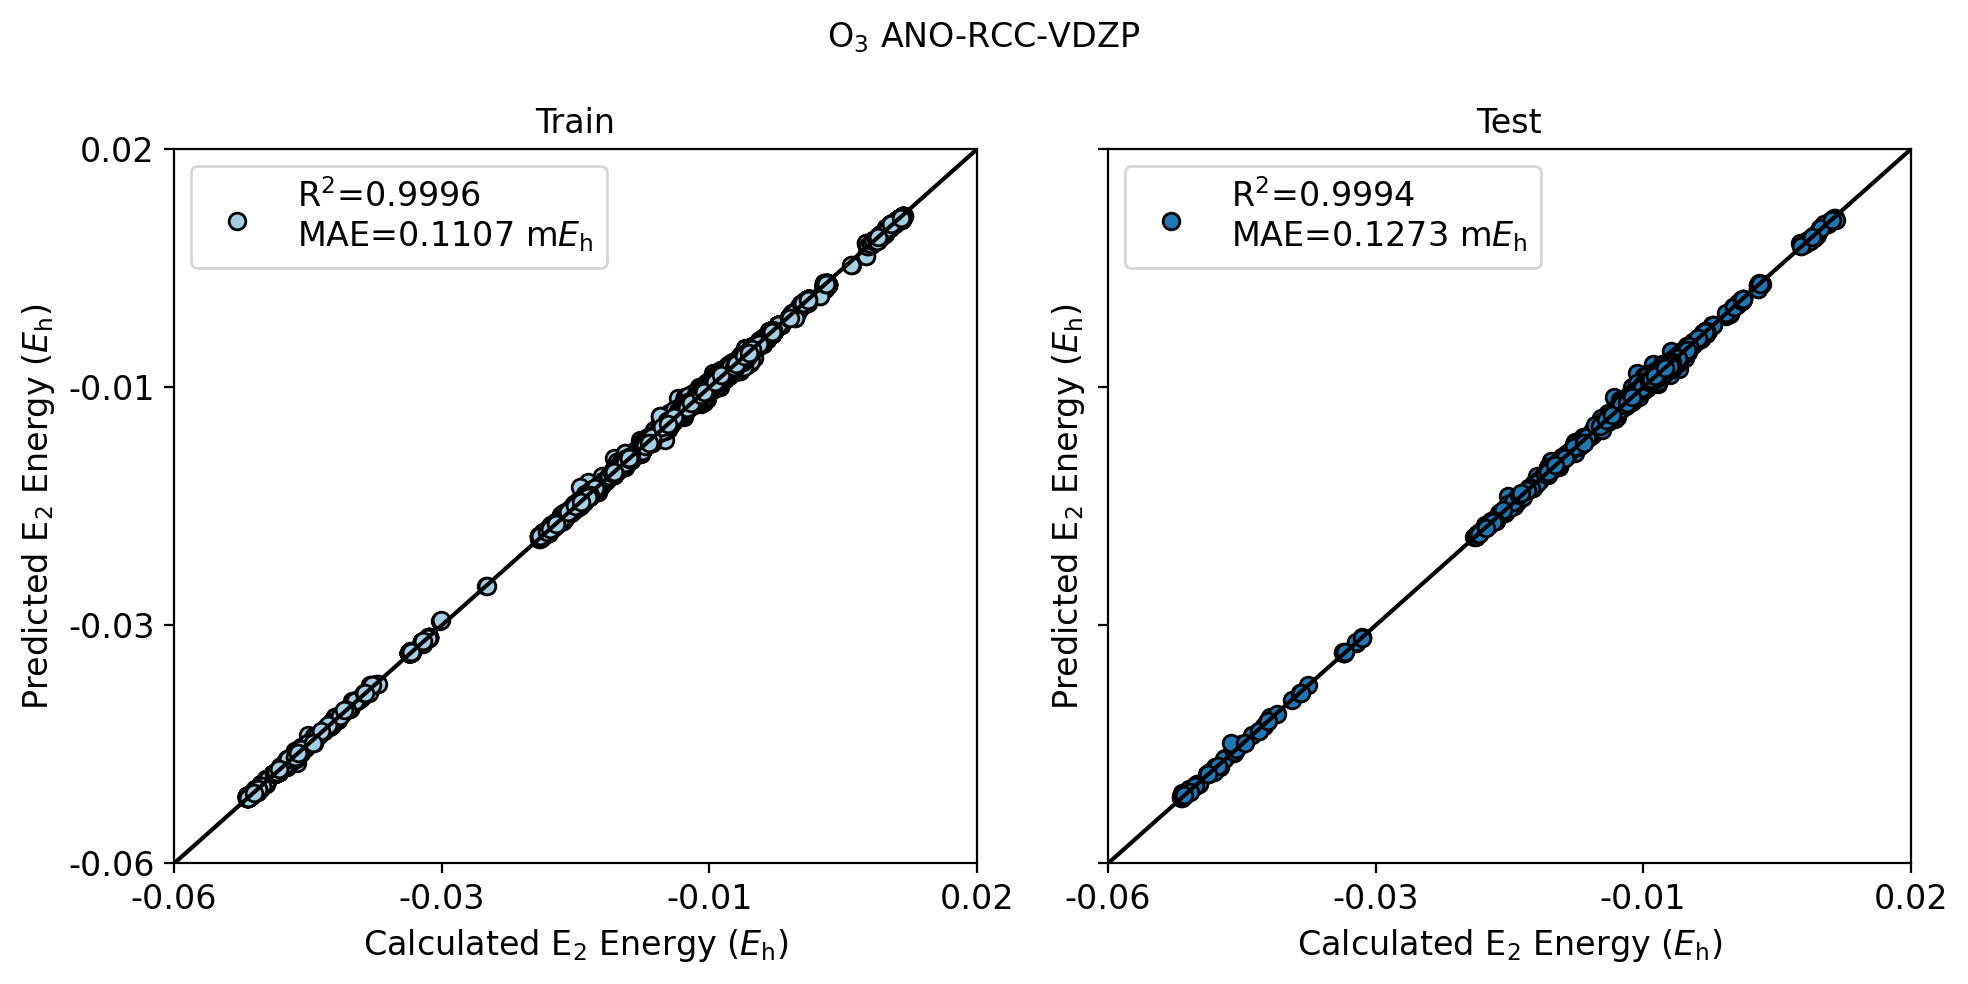

In [31]:
trainpairdf = pd.DataFrame(recover_train_list)
testpairdf = pd.DataFrame(recover_test_list)
pairerr={}

fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5),sharey=True)

truetrainpair, predtrainpair = np.hstack(trainpairdf[2]),np.hstack(trainpairdf[3])
train_r2_pair = r2_score(truetrainpair, predtrainpair)
train_mae_pair = 1e3*mean_absolute_error(truetrainpair, predtrainpair)
ax1.scatter(truetrainpair, predtrainpair,label='R$^{2}$='+f'{train_r2_pair:.4f}\nMAE={train_mae_pair:.4f}'+" m$E_{\mathrm{h}}$",color=pairedcp[0],edgecolors='k')
ax1.plot(np.arange(-1000,1000),np.arange(-1000,1000),'k')
ax1.set_xlabel('Calculated E$_2$ Energy ($E_{\mathrm{h}}$)')
ax1.set_ylabel('Predicted E$_2$ Energy ($E_{\mathrm{h}}$)')
ax1.set_title('Train')    
ax1.legend()  

truetestpair, predtestpair = np.hstack(testpairdf[2]),np.hstack(testpairdf[3])
test_r2_pair = r2_score(truetestpair, predtestpair)
test_mae_pair = 1e3*mean_absolute_error(truetestpair, predtestpair)
ax2.scatter(truetestpair, predtestpair,label='R$^{2}$='+f'{test_r2_pair:.4f}\nMAE={test_mae_pair:.4f}'+" m$E_{\mathrm{h}}$",color=pairedcp[1],edgecolors='k')
ax2.plot(np.arange(-1000,1000),np.arange(-1000,1000),'k')
ax2.set_xlabel('Calculated E$_2$ Energy ($E_{\mathrm{h}}$)')
ax2.set_ylabel('Predicted E$_2$ Energy ($E_{\mathrm{h}}$)')
ax2.set_title('Test')    
ax2.legend()    

mincorr, maxcorr= np.hstack([truetrainpair,truetestpair]).min(), np.hstack([truetrainpair,truetestpair]).max()
pct=0.50
bufferbot, buffertop = mincorr*pct, maxcorr*pct

# if 'H' in n:
bottom, top = mincorr-buffertop, maxcorr+buffertop

# else:
#     bottom, top = mincorr+-0.1, maxcorr+0.05

ax1.set_xlim(bottom,top)
ax1.set_xticks(np.linspace(bottom,top,4),[f"{i:.2f}" for i in np.linspace(bottom,top,4)])
ax1.set_ylim(bottom,top)
ax1.set_yticks(np.linspace(bottom,top,4),[f"{i:.2f}" for i in np.linspace(bottom,top,4)])    
ax2.set_xlim(bottom,top)
ax2.set_xticks(np.linspace(bottom,top,4),[f"{i:.2f}" for i in np.linspace(bottom,top,4)])    
ax2.set_ylim(bottom,top)
ax2.set_yticks(np.linspace(bottom,top,4),[f"{i:.2f}" for i in np.linspace(bottom,top,4)])    

fig.suptitle("O$_{3}$ ANO-RCC-VDZP")
plt.tight_layout()
plt.savefig(f'images/ozone_MBE2.png',dpi=300,bbox_inches='tight')    
plt.show()
pairerr = {"r2_train":train_r2_pair,"r2_test":test_r2_pair,"mae_train":train_mae_pair,"mae_test":test_mae_pair}

In [32]:
pd.DataFrame(np.vstack([testpairdf[1].astype(float),[mean_absolute_error(u,v) for u,v in np.vstack([testpairdf[2],testpairdf[3]]).T]])).T.sort_values(by=0).iloc[13]

0    140.750000
1      0.000132
Name: 0, dtype: float64

In [33]:
np.argmax([mean_absolute_error(u,v) for u,v in zip(testpairdf[2],testpairdf[3])])

np.int64(18)

In [34]:
trainpairmae = np.array([mean_absolute_error(u,v) for u,v in np.vstack([trainpairdf[2],trainpairdf[3]]).T])
testpairmae = np.array([mean_absolute_error(u,v) for u,v in np.vstack([testpairdf[2],testpairdf[3]]).T])

In [35]:
np.argsort(trainpairmae)[-5:],np.round(1e3*trainpairmae[np.argsort(trainpairmae)[-10:]],4)

(array([242, 240, 199, 258, 261]),
 array([0.1809, 0.1874, 0.1977, 0.213 , 0.2183, 0.2218, 0.2257, 0.2281,
        0.458 , 0.4651]))

In [36]:
cleanedtrain = traincorrE2.drop(index=traincorrE2.iloc[np.argsort(trainpairmae)[-10:]].index)

In [37]:
traincorrE2.iloc[np.argsort(trainpairmae)[-10:]]

,basis set,Angle ($^{\circ}$),E$_{2}^{\text{Calculated}}$,E$_{2}^{\text{Predicted}}$,E$_{\text{CASPT2}}^{\text{Calculated}}$,E$_{\text{CASSCF}}^{\text{Calculated}}$,E2,E$_{\text{CASPT2}}^{\text{Predicted}}$
ANO-RCC-VDZP_163.25,ANO-RCC-VDZP,163.25,-0.537042,-0.539099,-225.013842,-224.476802,0.0,-225.015901
ANO-RCC-VDZP_108.25,ANO-RCC-VDZP,108.25,-0.529480,-0.531148,-225.116753,-224.587277,0.0,-225.118425
ANO-RCC-VDZP_107.00,ANO-RCC-VDZP,107.00,-0.528935,-0.525259,-225.114715,-224.585779,0.0,-225.111038
ANO-RCC-VDZP_180.00,ANO-RCC-VDZP,180.00,-0.528918,-0.524172,-224.978085,-224.449172,0.0,-224.973344
ANO-RCC-VDZP_106.75,ANO-RCC-VDZP,106.75,-0.528830,-0.529623,-225.114269,-224.585441,0.0,-225.115064
ANO-RCC-VDZP_109.00,ANO-RCC-VDZP,109.00,-0.529799,-0.527691,-225.117824,-224.588026,0.0,-225.115716
ANO-RCC-VDZP_109.25,ANO-RCC-VDZP,109.25,-0.529906,-0.525499,-225.118157,-224.588251,0.0,-225.113749
ANO-RCC-VDZP_106.50,ANO-RCC-VDZP,106.50,-0.528723,-0.526286,-225.113811,-224.585090,0.0,-225.111376
ANO-RCC-VDZP_106.25,ANO-RCC-VDZP,106.25,-0.529026,-0.532730,-225.110997,-224.581972,0.0,-225.114702
ANO-RCC-VDZP_106.00,ANO-RCC-VDZP,106.00,-0.528834,-0.535166,-225.110435,-224.581600,0.0,-225.116766


In [38]:
np.round(1e3*mean_absolute_error(cleanedtrain['E$_{2}^{\text{Calculated}}$'],cleanedtrain['E$_{2}^{\text{Predicted}}$']),4)

np.float64(1.0398)

In [39]:
np.round(r2_score(cleanedtrain['E$_{2}^{\text{Calculated}}$'],cleanedtrain['E$_{2}^{\text{Predicted}}$']),4)

np.float64(0.9049)

<BarContainer object of 273 artists>

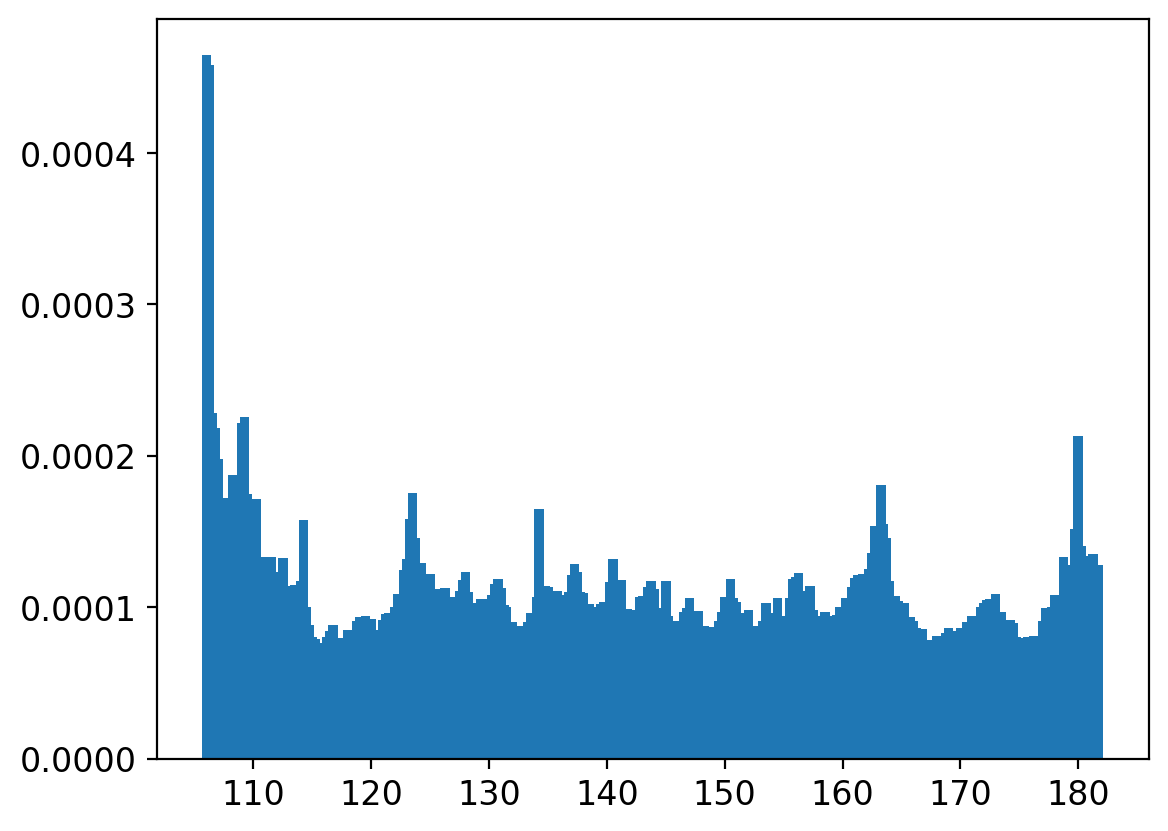

In [40]:
plt.bar(*np.vstack([trainpairdf[1].astype(float),[mean_absolute_error(u,v) for u,v in np.vstack([trainpairdf[2],trainpairdf[3]]).T]]))

<BarContainer object of 31 artists>

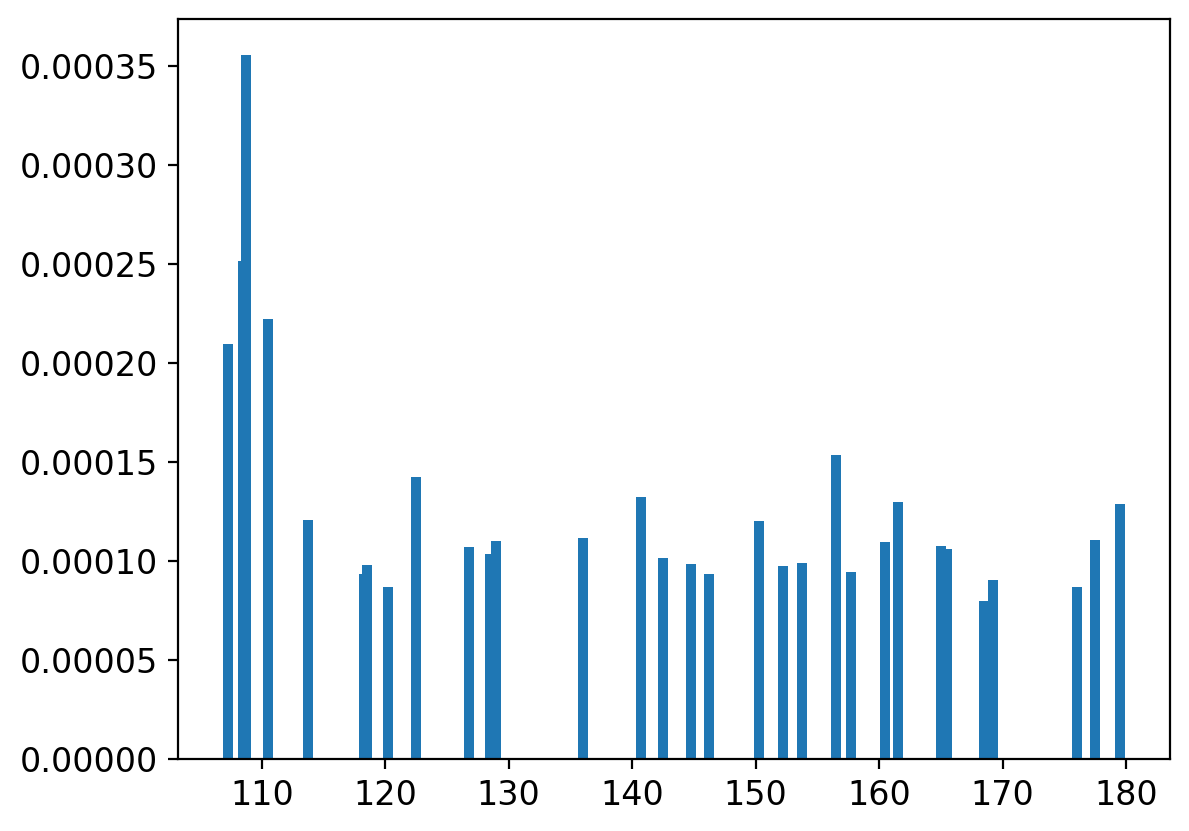

In [41]:
plt.bar(*np.vstack([testpairdf[1].astype(float),[mean_absolute_error(u,v) for u,v in np.vstack([testpairdf[2],testpairdf[3]]).T]]))

<BarContainer object of 273 artists>

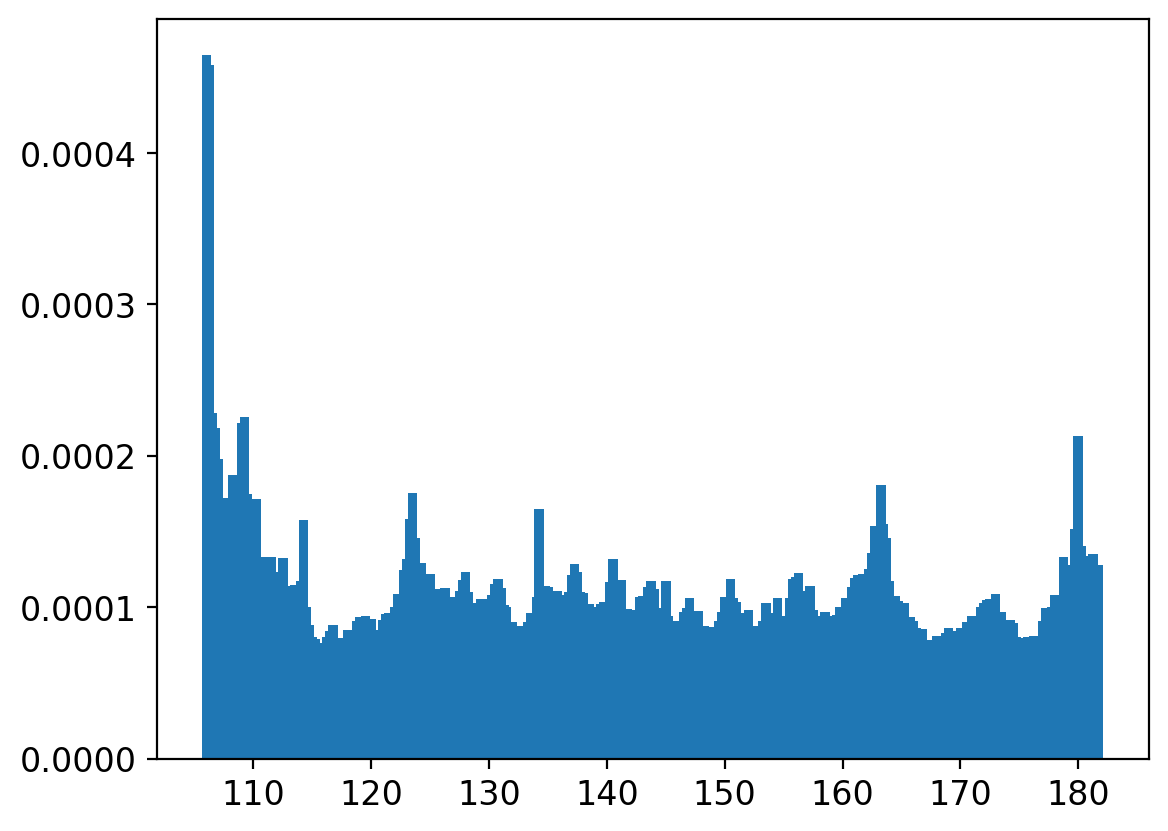

In [42]:
plt.bar(*np.vstack([trainpairdf[1].astype(float),[mean_absolute_error(u,v) for u,v in np.vstack([trainpairdf[2],trainpairdf[3]]).T]]))

In [43]:
stackeddata ={'Pair-Energies':{'Train':mean_absolute_error(truetrainpair, predtrainpair)*1e3,'Test':mean_absolute_error(truetestpair, predtestpair)*1e3},
"Correlation Energies":{'Train':mean_absolute_error(true_train,pred_train)*1e3,'Test':mean_absolute_error(pred_test,true_test)*1e3}}
pd.DataFrame(stackeddata).to_excel("MAE_stacked_MB.xlsx")

In [44]:
# meltcorrerr = pd.DataFrame.from_dict(traincorrerr).loc[['mae_train','mae_test']].T.rename(columns={'mae_train':'Train','mae_test':'Test'}).reset_index().melt(id_vars=['index'], value_vars=['Train','Test'])
# meltpairerr = pd.DataFrame.from_dict(pairerr).loc[['mae_train','mae_test']].T.rename(columns={'mae_train':'Train','mae_test':'Test'}).reset_index().melt(id_vars=['index'], value_vars=['Train','Test'])
# fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5),sharey=True)
# sns.barplot(data=meltpairerr,x='index',y='value',hue='variable',palette=pairedcp[4:6],ax=ax1)
# ax1.set_ylabel('Mean Absolute Error (m$E_{\mathrm{h}}$)')
# ax1.set_xlabel('Structures')
# ax1.set_title('Pair-Energies')
# ax1.set_ylim(0,2.5)
# sns.barplot(data=meltcorrerr,x='index',y='value',hue='variable',palette=pairedcp[4:6],ax=ax2)
# # ax2.set_ylabel('Mean Absolute Error (m$E_{\mathrm{h}}$)')
# ax2.set_ylabel('')
# ax2.set_xlabel('Structures')
# ax2.set_title('Correlation Energies')

# plt.tight_layout()
# plt.savefig('images/MAE_bar.png',dpi=300,bbox_inches='tight')
# plt.show()

In [45]:
import shap
explainer = shap.Explainer(model.predict, X_test)
shap_values = explainer(X_test)

dffeat=pd.DataFrame(shap_values.abs.values.mean(axis=0),index=train_df.drop(columns=['Pair_Energies']).columns,columns=['shap']).rename(index={'1':'$\mathbf{b}$'}).reset_index().rename(columns={'index':'feat'}).sort_index().sort_values(by=['shap','feat'],ascending=False)
# dffeat['rename']=len(dffeat)*[1]
with open('ozone_MB_feature_names.txt','w') as f:
    for i in dffeat['feat'].values:
        f.write(i+'\n')

# with open('feature_names.txt','w') as f:
#     for i in dffeat['feat'].values:
#         f.write(i+'\n')
dffeat.to_excel('ozone_MB_SHAP.xlsx')
# dffeat = pd.read_excel('ozone_MB_SHAP.xlsx')

PermutationExplainer explainer: 2914it [02:30, 18.38it/s]                                                                                                                                      


0 [0, 35]
1 [35, 70]
2 [70, 105]


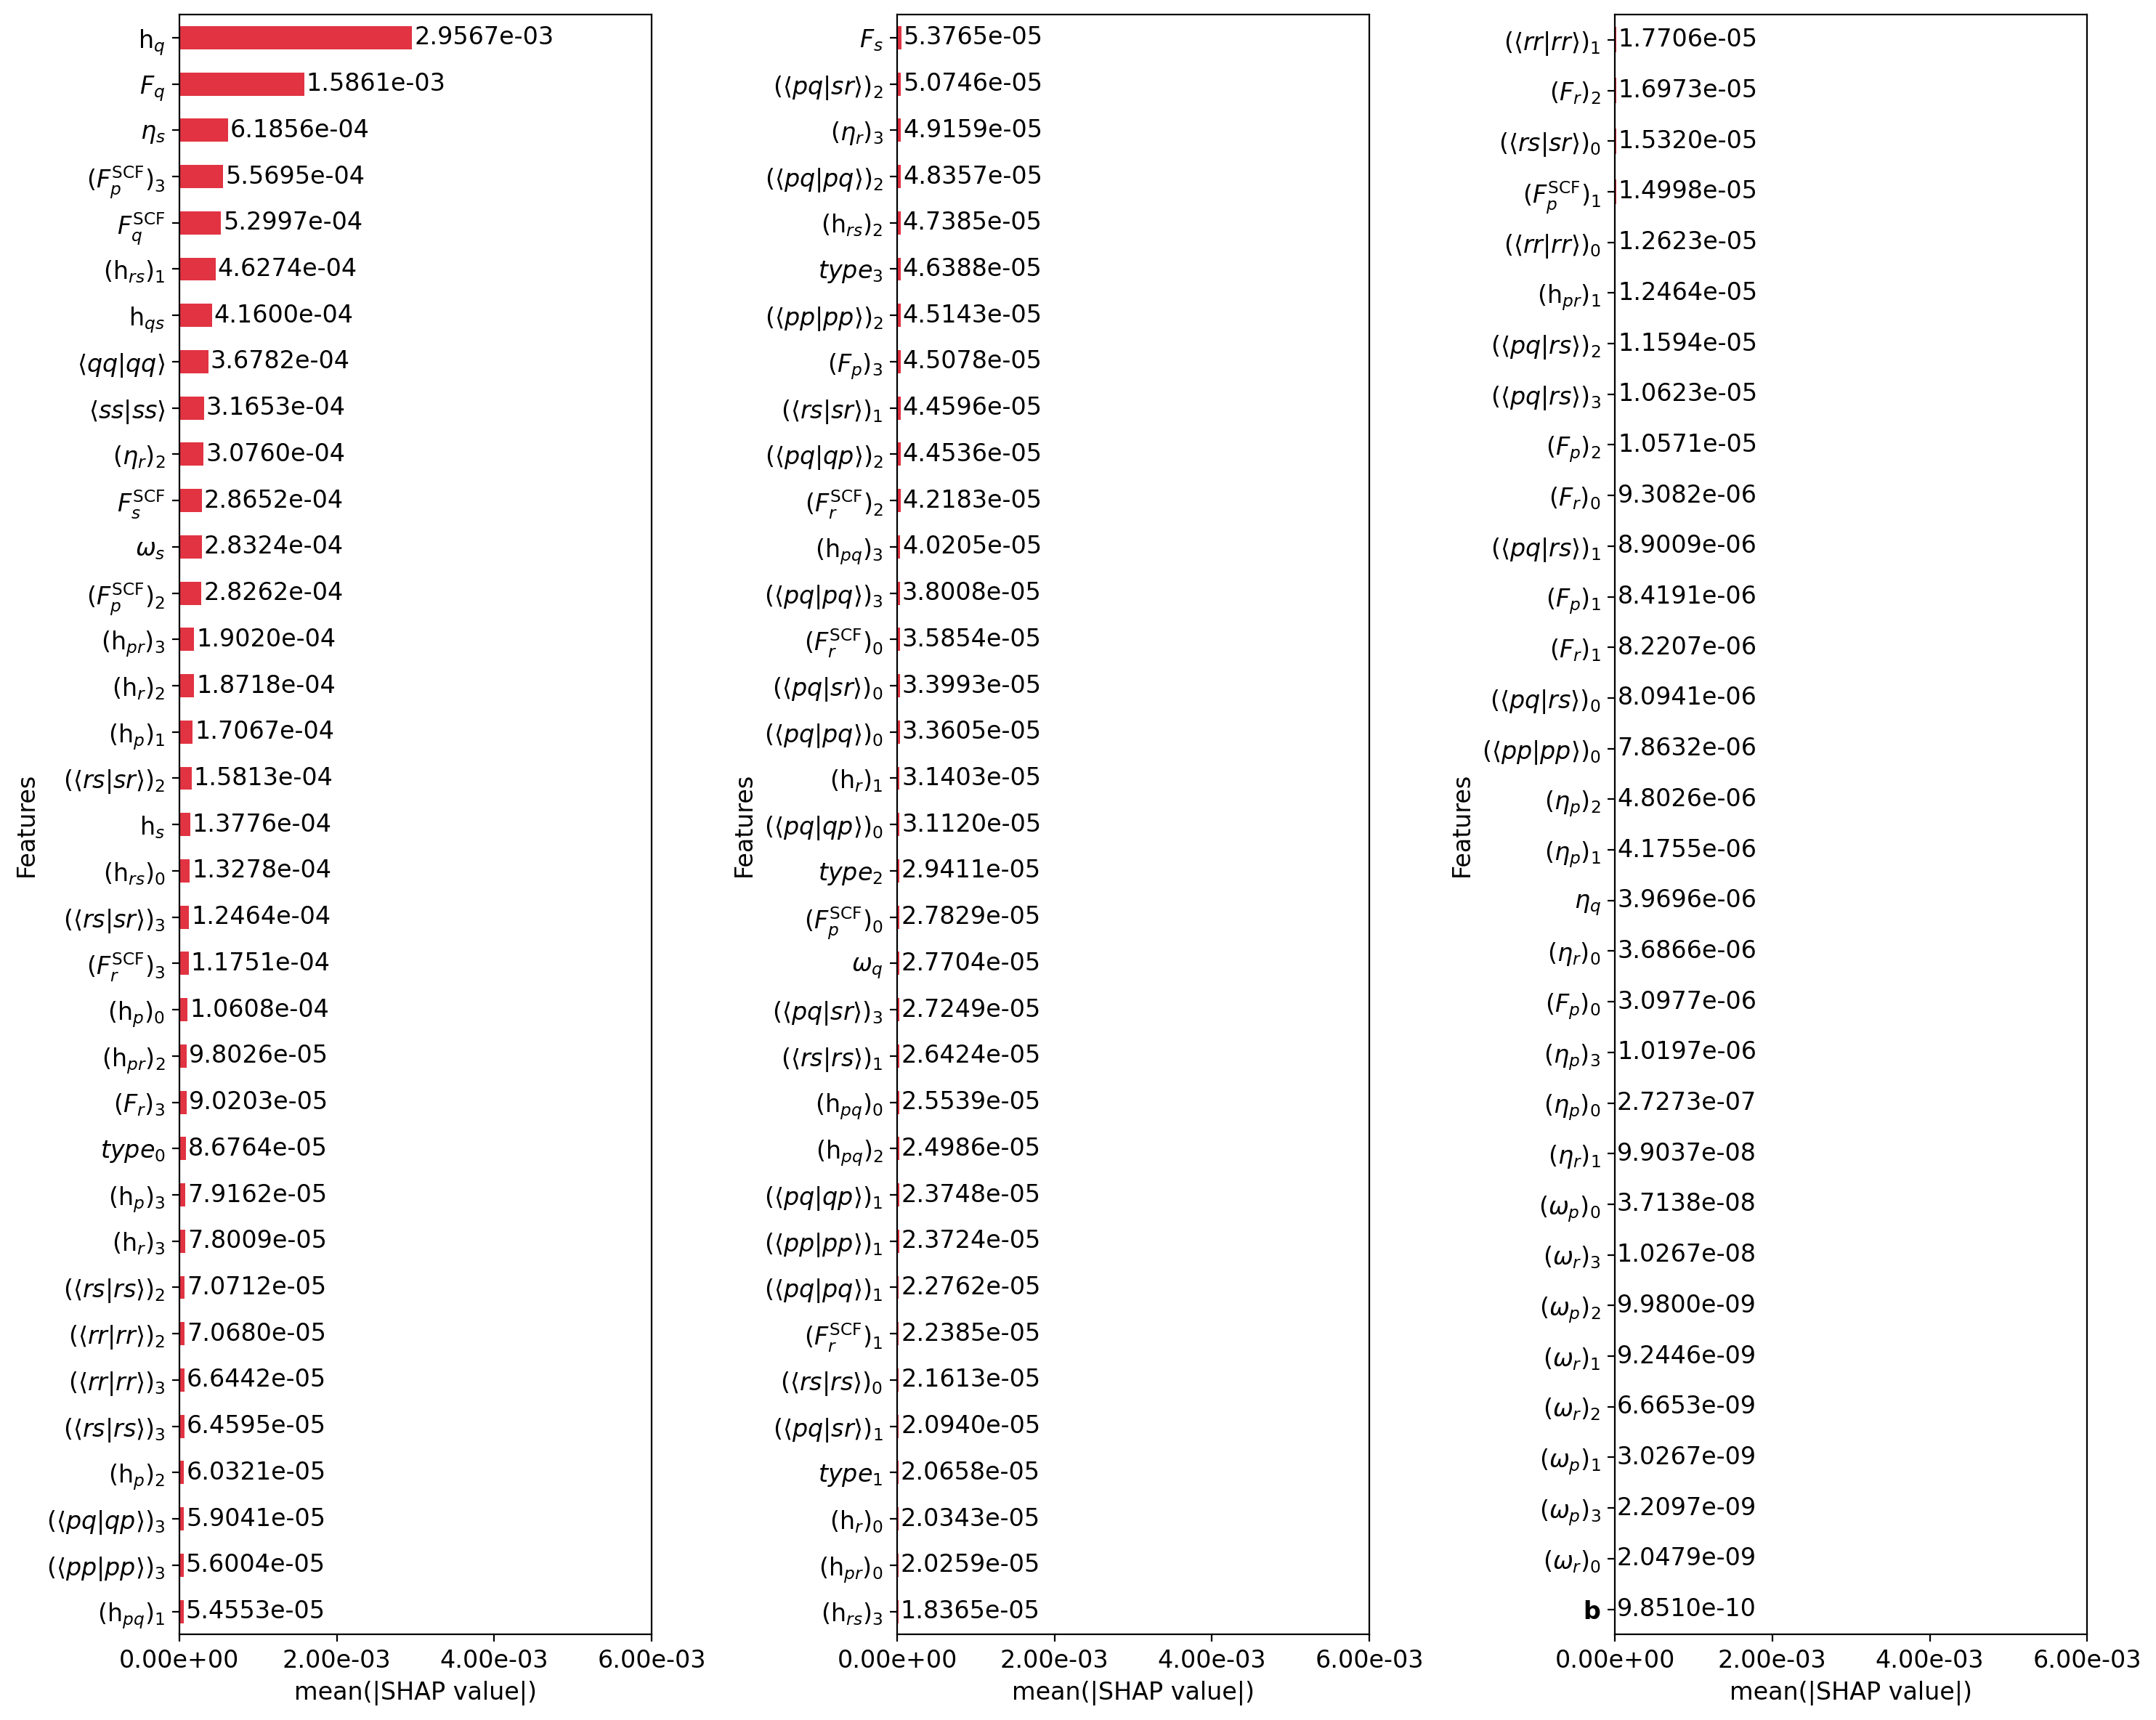

In [46]:
color_map=sns.color_palette('rocket',6)
fontsize = 12
fig, ax = plt.subplots(1,3,figsize=(15,12))
for idx, i in enumerate([[ 0,  35], [35,  70], [70, 105]]):
    print(idx,i)
    feat_1 = dffeat.iloc[i[0]:i[1]]
    ax[idx]=feat_1.sort_values(by=['shap','feat']).plot.barh(x='feat',y='shap',legend=False,color=color_map[3],fontsize=fontsize,ax=ax[idx])
    ax[idx].bar_label(ax[idx].containers[0], fmt='%.4e',fontsize=fontsize,padding=1)
    top_max = 6e-3
    ax[idx].set_xlim(0,top_max)
    ax[idx].set_xticks(np.linspace(0,top_max,4),[f"{i:.2e}" for i in np.linspace(0,top_max,4)])
    ax[idx].set_ylabel('Features',fontsize=fontsize)
    ax[idx].set_xlabel('mean(|SHAP value|)',fontsize=fontsize)

fig.subplots_adjust(wspace=0, hspace=0)

plt.tight_layout()
plt.savefig('images/ozone_MB_shap_bar.png',dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_243462/1669817861.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


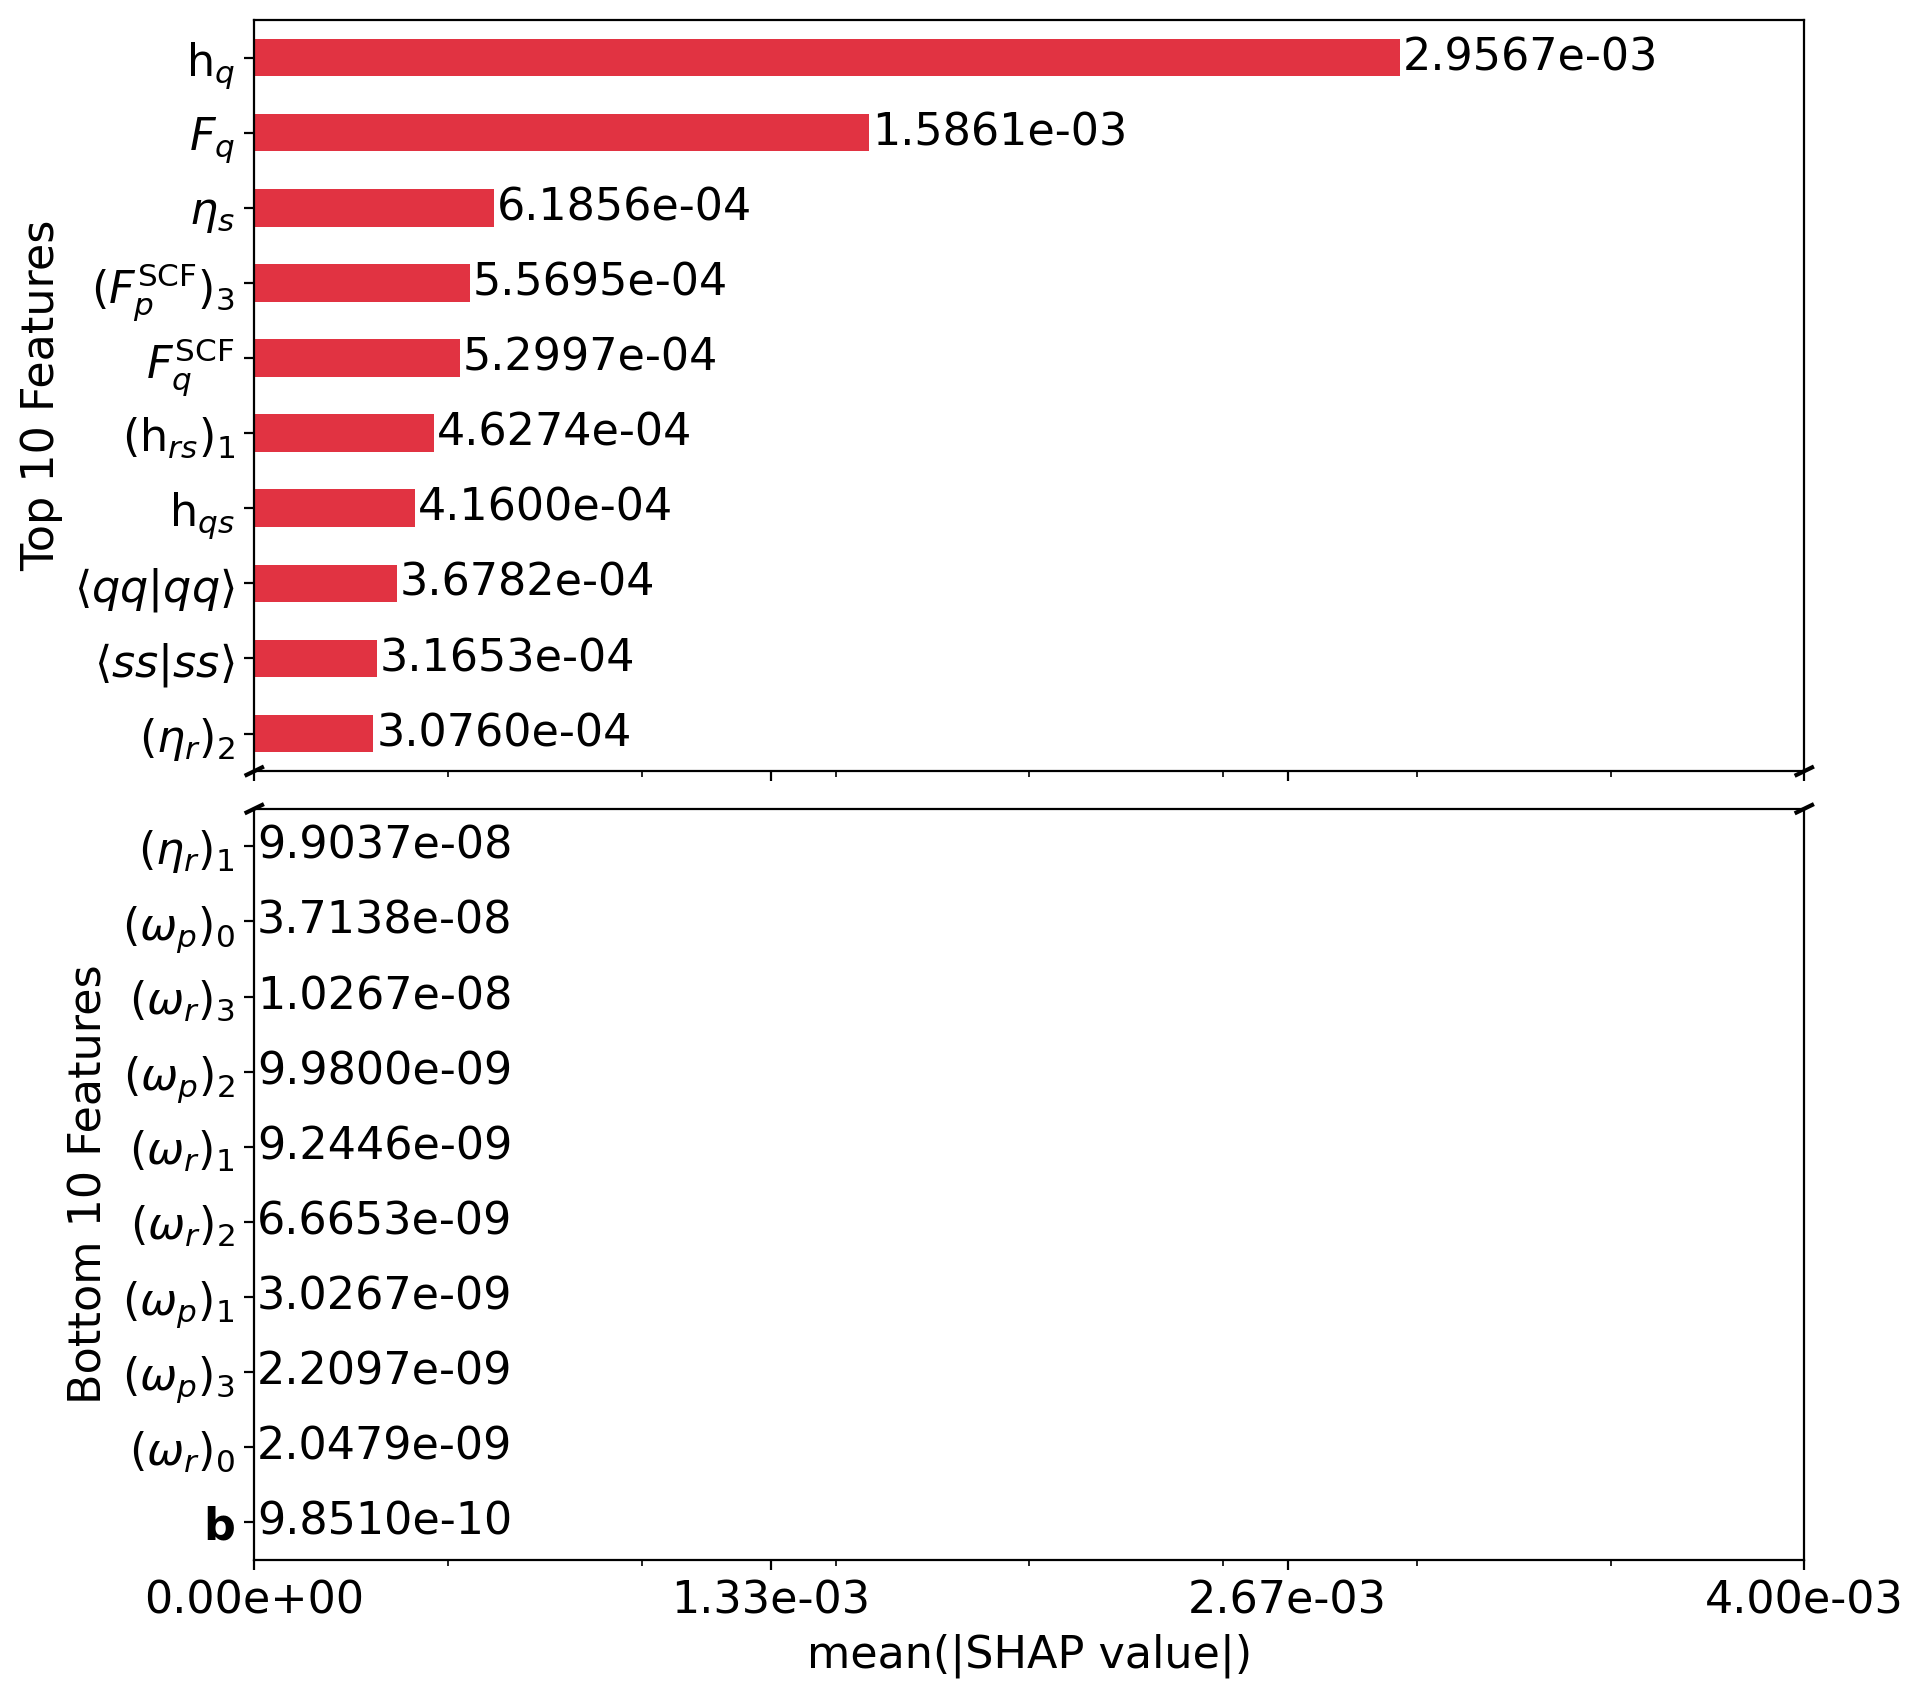

In [57]:
# fig, ax = plt.subplots(1,1,figsize=(12,12))
# fontsize = 16
# pd.concat([dffeat.sort_values(by='shap').iloc[0:10],dffeat.sort_values(by='shap').iloc[-10:]]).plot.barh(x='feat',y='shap',legend=False,color=color_map[3],fontsize=fontsize,ax=ax)
# ax.bar_label(ax.containers[0], fmt='%.4e',fontsize=fontsize,padding=1)
# top_max = 4.5e-3
# ax.set_xlim(0,top_max)
# ax.set_xticks(np.linspace(0,top_max,4),[f"{i:.2e}" for i in np.linspace(0,top_max,4)])
# ax.set_ylabel('Features',fontsize=fontsize)
# ax.set_xlabel('mean(|SHAP value|)',fontsize=fontsize)

# fig.subplots_adjust(wspace=0, hspace=0)

# plt.tight_layout()
# plt.savefig('images/minmax_ozone_MB_shap_bar.png',dpi=300, bbox_inches='tight')
# plt.show()


import matplotlib.gridspec as gridspec

# Assuming you already have dffeat and color_map defined
top10 = dffeat.sort_values(by='shap', ascending=True).iloc[-10:]
bottom10 = dffeat.sort_values(by='shap', ascending=True).iloc[:10]

fontsize = 16
# top_max = 1.1e-3
top_max = 4e-3
# top_max = 5e-3

# Create a figure with two subplots, sharing x-axis
fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1], hspace=0.05)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

# Plot top 10
top10.plot.barh(x='feat', y='shap', ax=ax_top, legend=False, color=color_map[3], fontsize=fontsize)
ax_top.bar_label(ax_top.containers[0], fmt='%.4e', fontsize=fontsize, padding=1)

# Plot bottom 10
bottom10.plot.barh(x='feat', y='shap', ax=ax_bot, legend=False, color=color_map[3], fontsize=fontsize)
ax_bot.bar_label(ax_bot.containers[0], fmt='%.4e', fontsize=fontsize, padding=1)

# Hide x-axis labels on top plot
plt.setp(ax_top.get_xticklabels(), visible=False)
ax_top.set_xlabel("")
ax_bot.set_xlabel('mean(|SHAP value|)', fontsize=fontsize)

# Y labels
ax_top.set_ylabel('Top 10 Features', fontsize=fontsize)
ax_bot.set_ylabel('Bottom 10 Features', fontsize=fontsize)

# Shared limits and ticks
ax_top.set_xlim(0, top_max)
ax_bot.set_xlim(0, top_max)
ax_bot.set_xticks(np.linspace(0, top_max, 4))
ax_bot.set_xticklabels([f"{i:.2e}" for i in np.linspace(0, top_max, 4)], fontsize=fontsize)

# Add axis break indicators (diagonal lines)
d = .005  # size of diagonal lines in axes coordinates
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=ax_bot.transAxes)
ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

plt.tight_layout()
plt.savefig('images/minmax_ozone_MB_shap_bar.png',dpi=300, bbox_inches='tight')
plt.show()

In [48]:
# # plt.figure(figsize=(8,13))
# color_map=sns.color_palette('rocket',6)
# fontsize = 5

# feat_2 = dffeat.sort_values(by=['shap','feat']).iloc[:63]
# feat_1 = dffeat.sort_values(by=['shap','feat']).iloc[63:]


# ax1=feat_1.sort_values(by=['shap','feat']).plot.barh(x='feat',y='shap',legend=False,color=color_map[3],fontsize=fontsize,ax=ax1)
# ax1.bar_label(ax1.containers[0], fmt='%.4e',fontsize=fontsize,padding=1)
# ax1.set_xlim(0,5e-4)
# ax1.set_xticks(np.linspace(0,5e-4,4),[f"{i:.2e}" for i in np.linspace(0,5e-4,4)])
# ax1.set_ylabel('Features',fontsize=fontsize)
# ax1.set_xlabel('mean(|SHAP value|)',fontsize=fontsize)

# ax2=feat_2.sort_values(by=['shap','feat']).plot.barh(x='feat',y='shap',legend=False,color=color_map[3],fontsize=fontsize,ax=ax2)
# ax2.bar_label(ax2.containers[0], fmt='%.4e',fontsize=fontsize,padding=1)
# ax2.set_xlim(0,5e-4)
# ax2.set_xticks(np.linspace(0,5e-4,4),[f"{i:.2e}" for i in np.linspace(0,5e-4,4)])
# ax2.set_ylabel('')
# ax2.set_xlabel('mean(|SHAP value|)',fontsize=fontsize)

# plt.tight_layout()
# # os.mkdir('images')
# plt.savefig('images/Hn_shap_bar.png',dpi=300, bbox_inches='tight')
# plt.show()



In [49]:
dffeat.sort_values(by='shap').iloc[-10:]['feat'].to_list()

['$(\\eta_{r})_{2}$',
 '$\\langle ss \\vert ss \\rangle$',
 '$\\langle qq \\vert qq \\rangle$',
 'h$_{qs}$',
 '(h$_{rs}$)$_{1}$',
 '$F_{q}^{\\text{SCF}}$',
 '$(F_{p}^{\\text{SCF}})_{3}$',
 '$\\eta_{s}$',
 '$F_{q}$',
 'h$_{q}$']

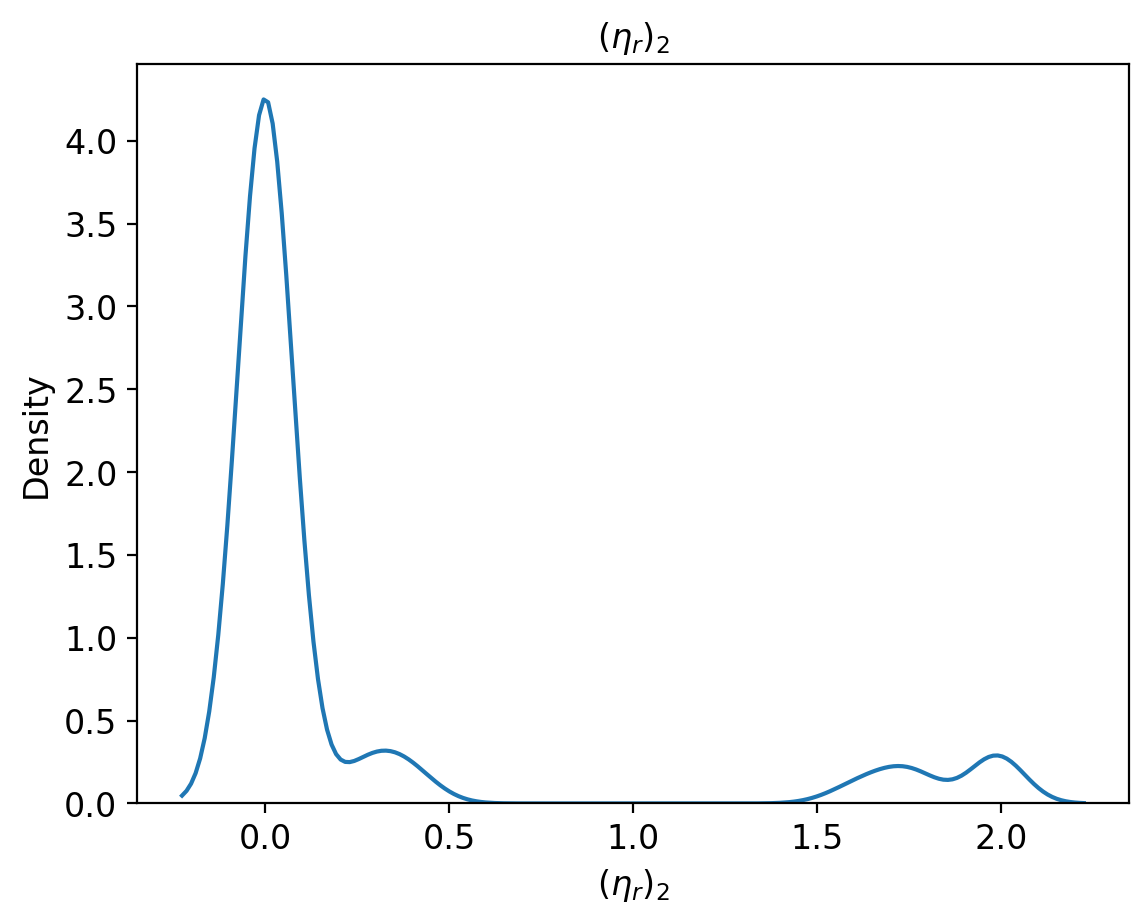

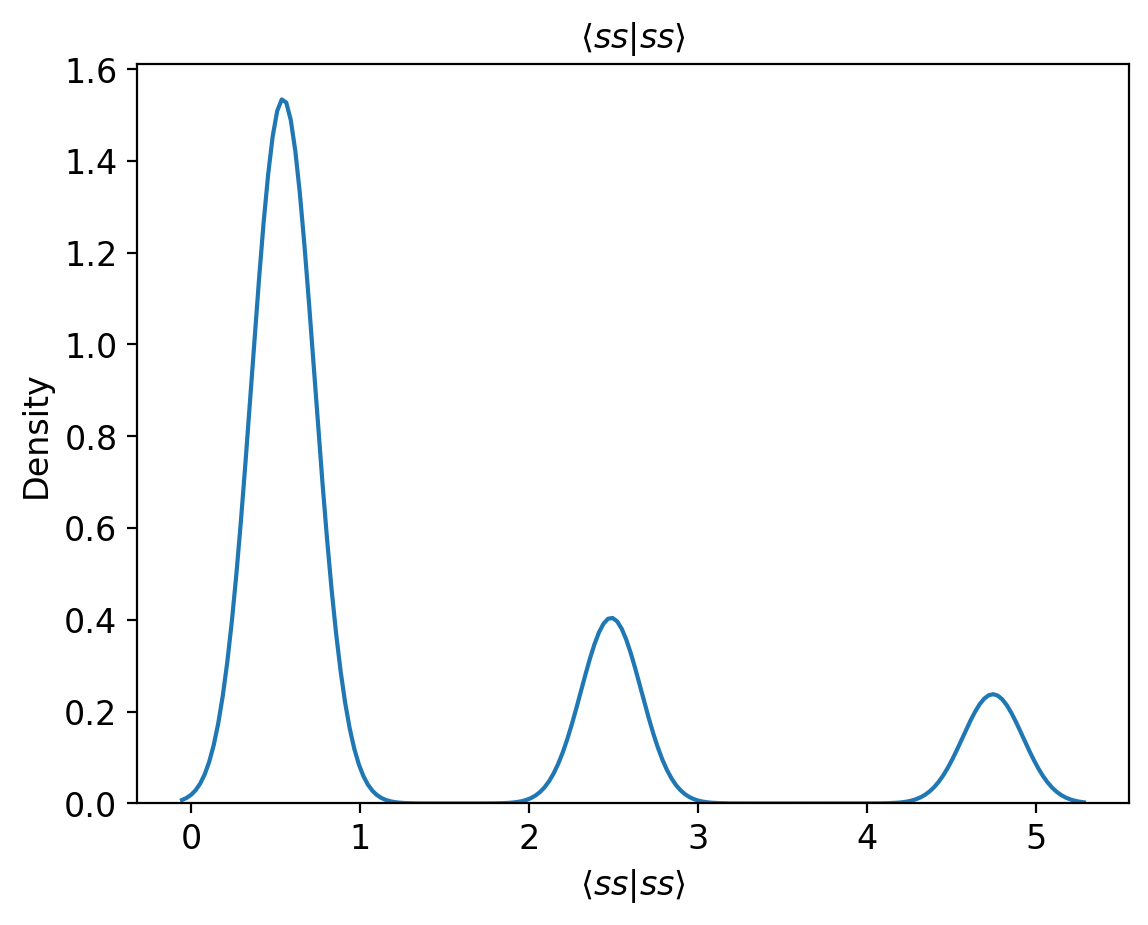

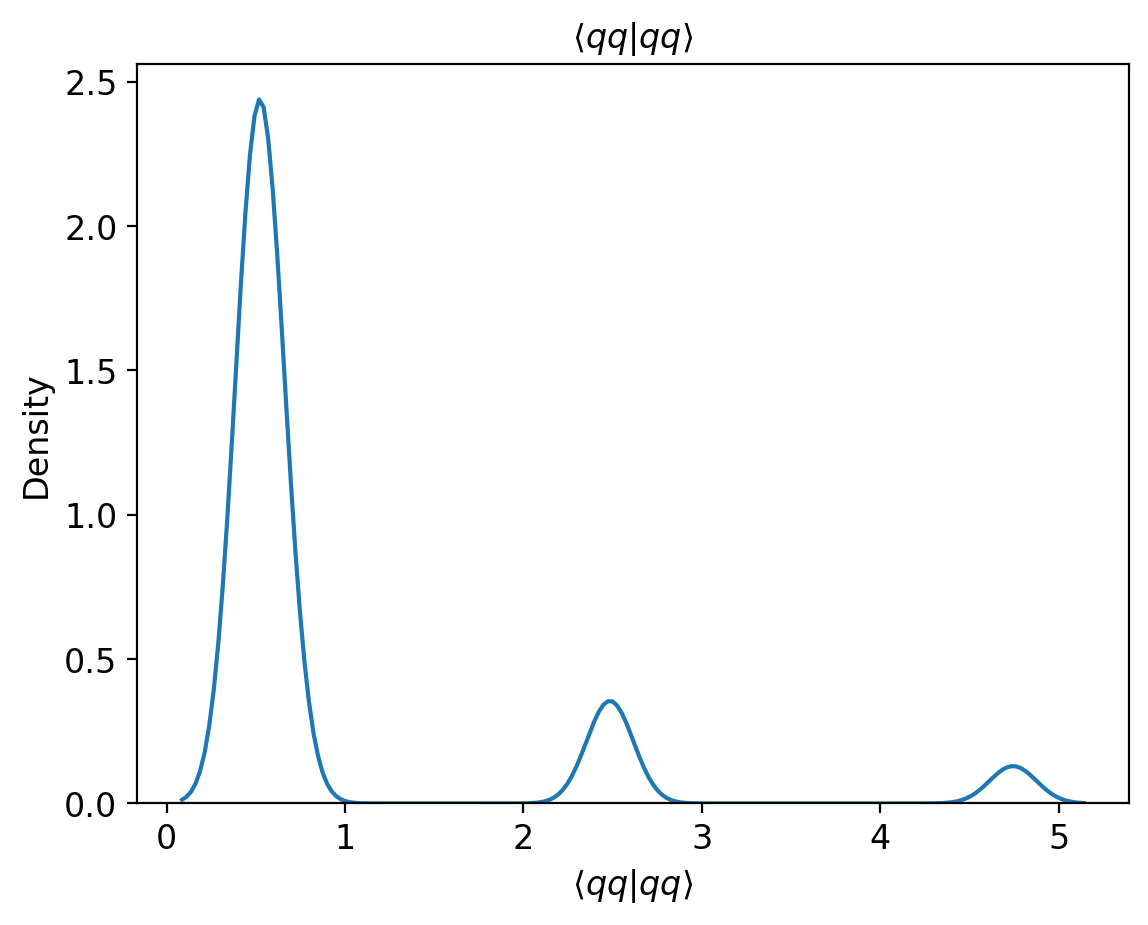

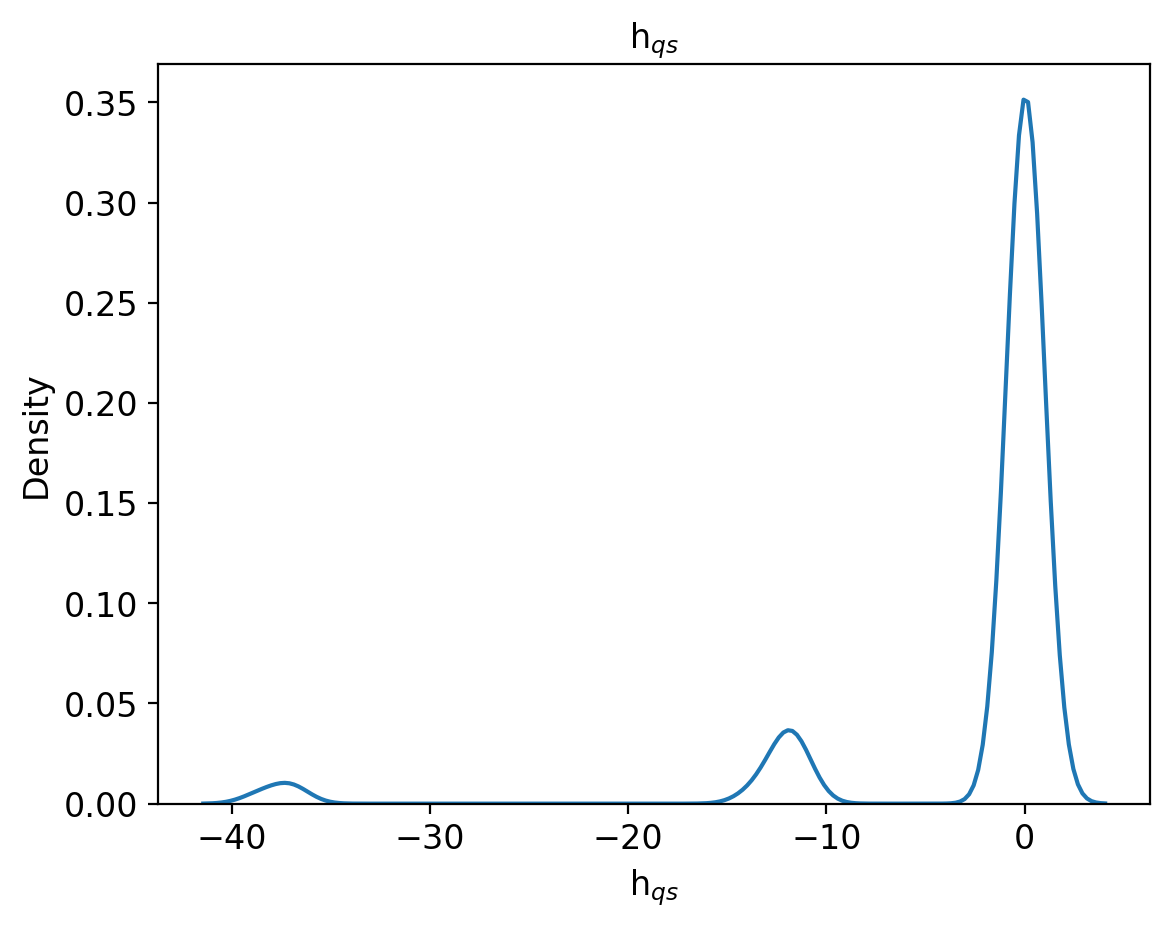

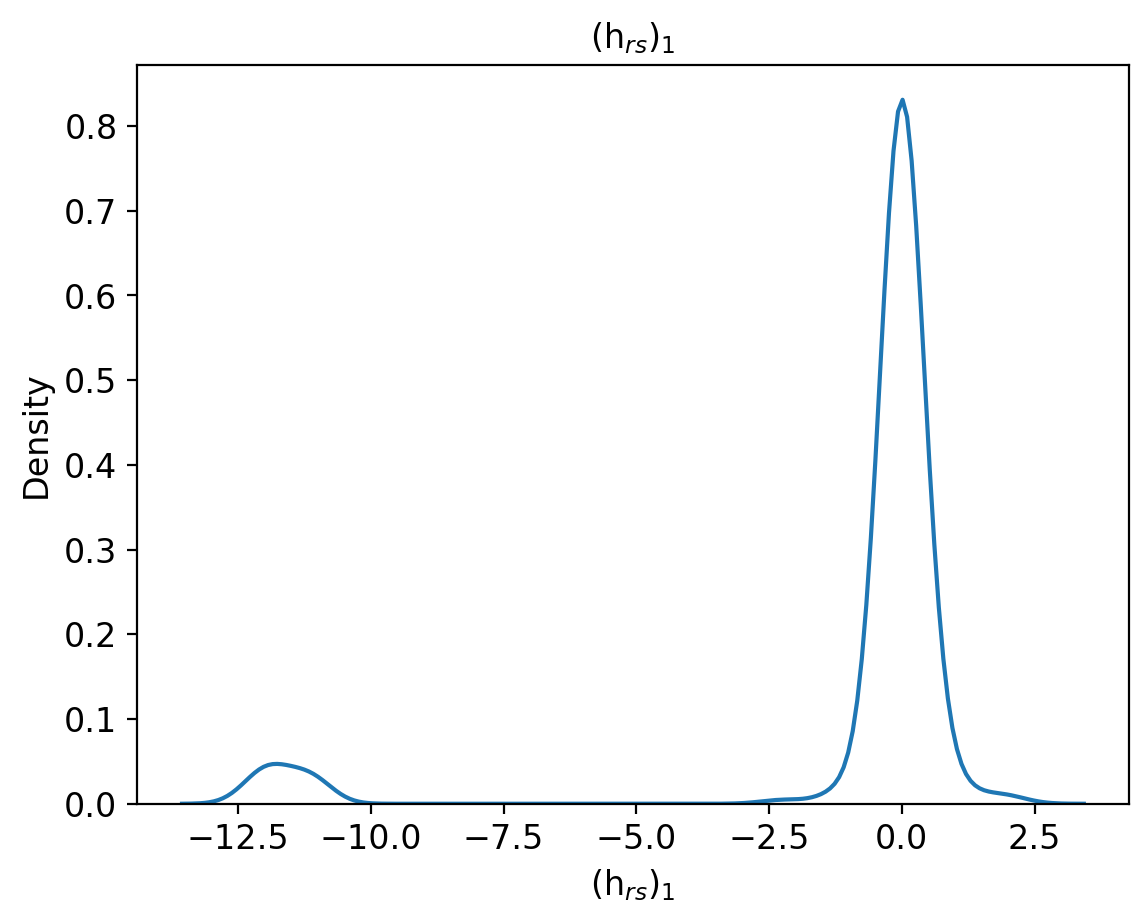

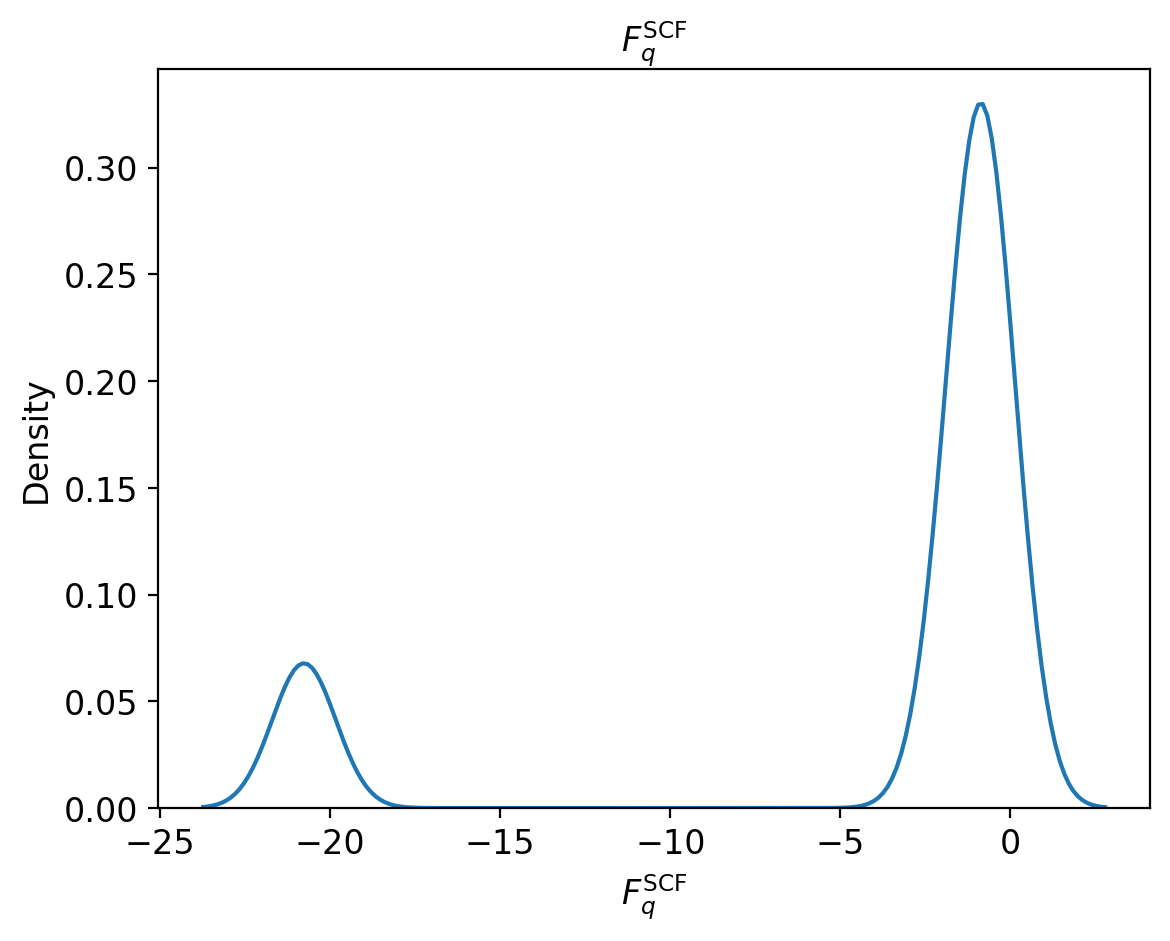

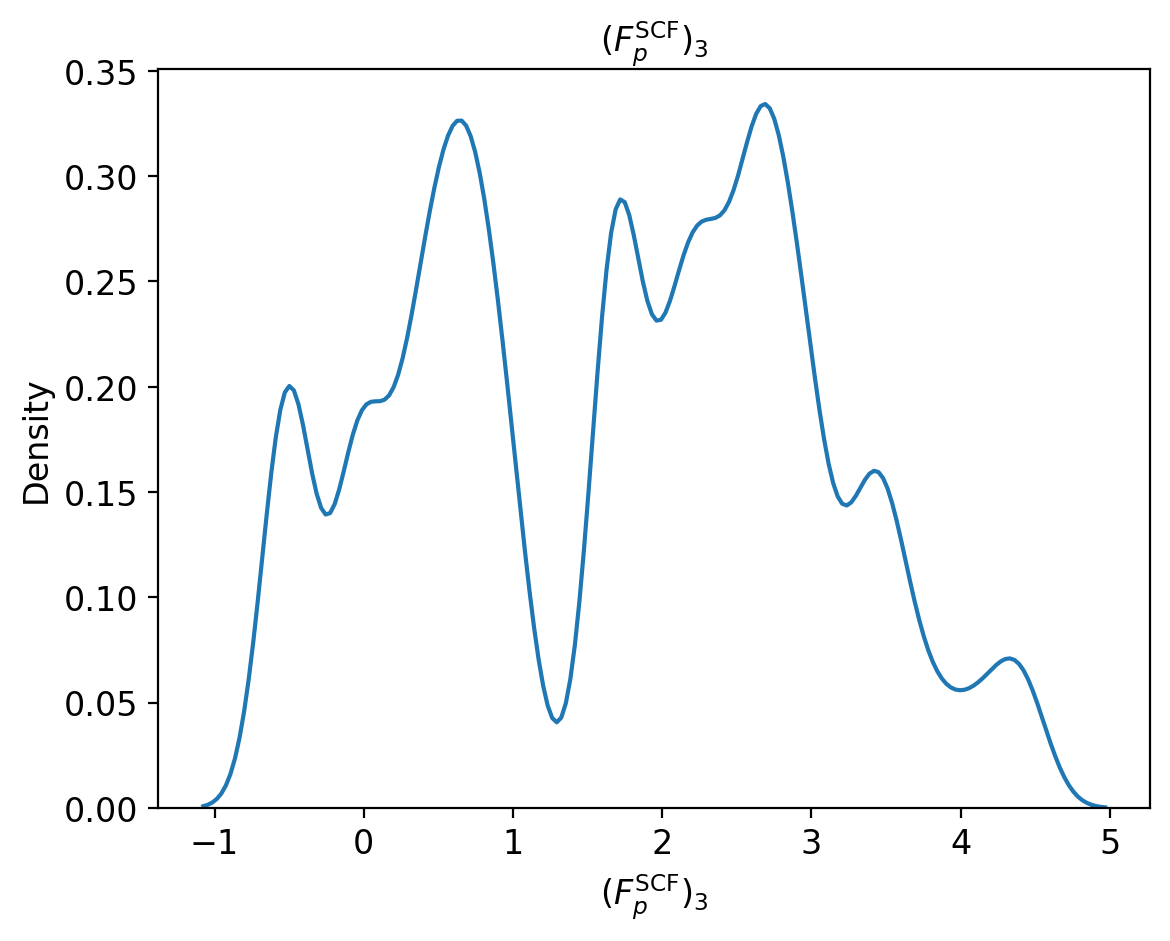

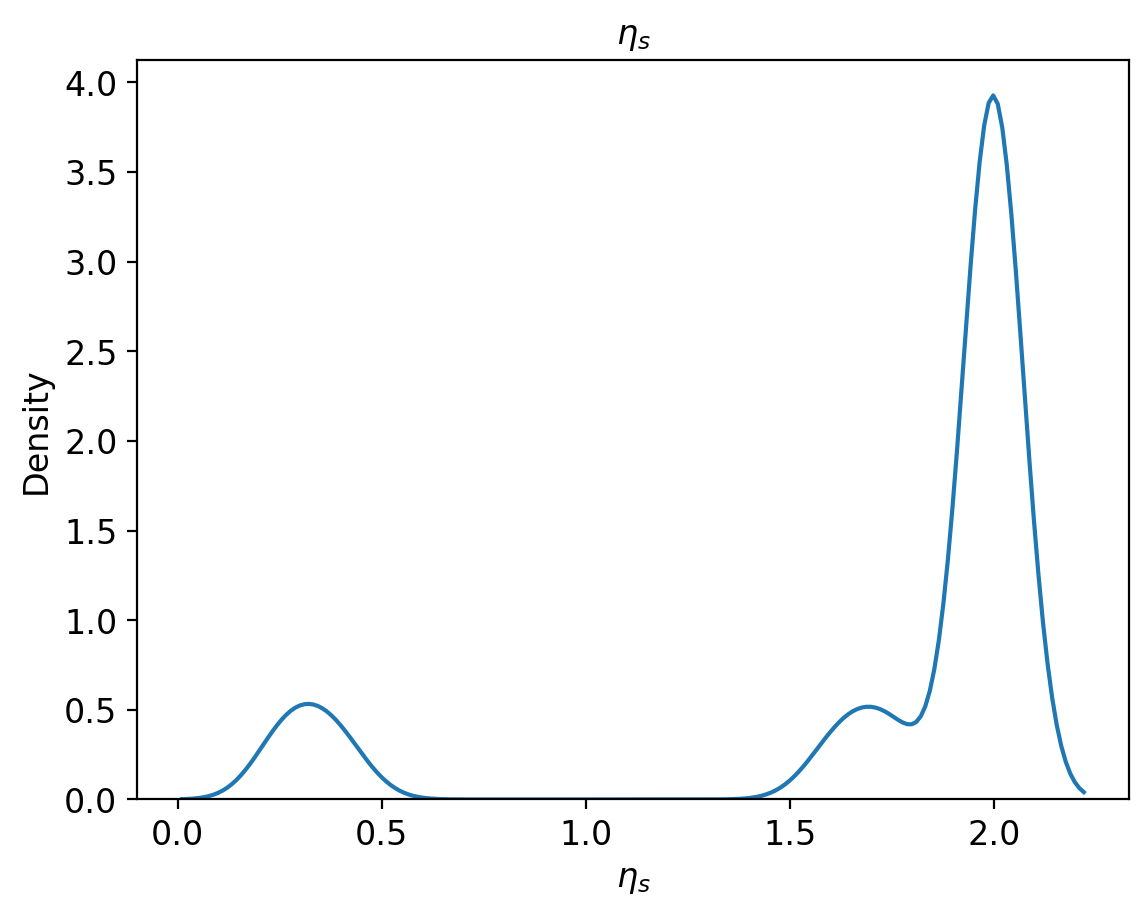

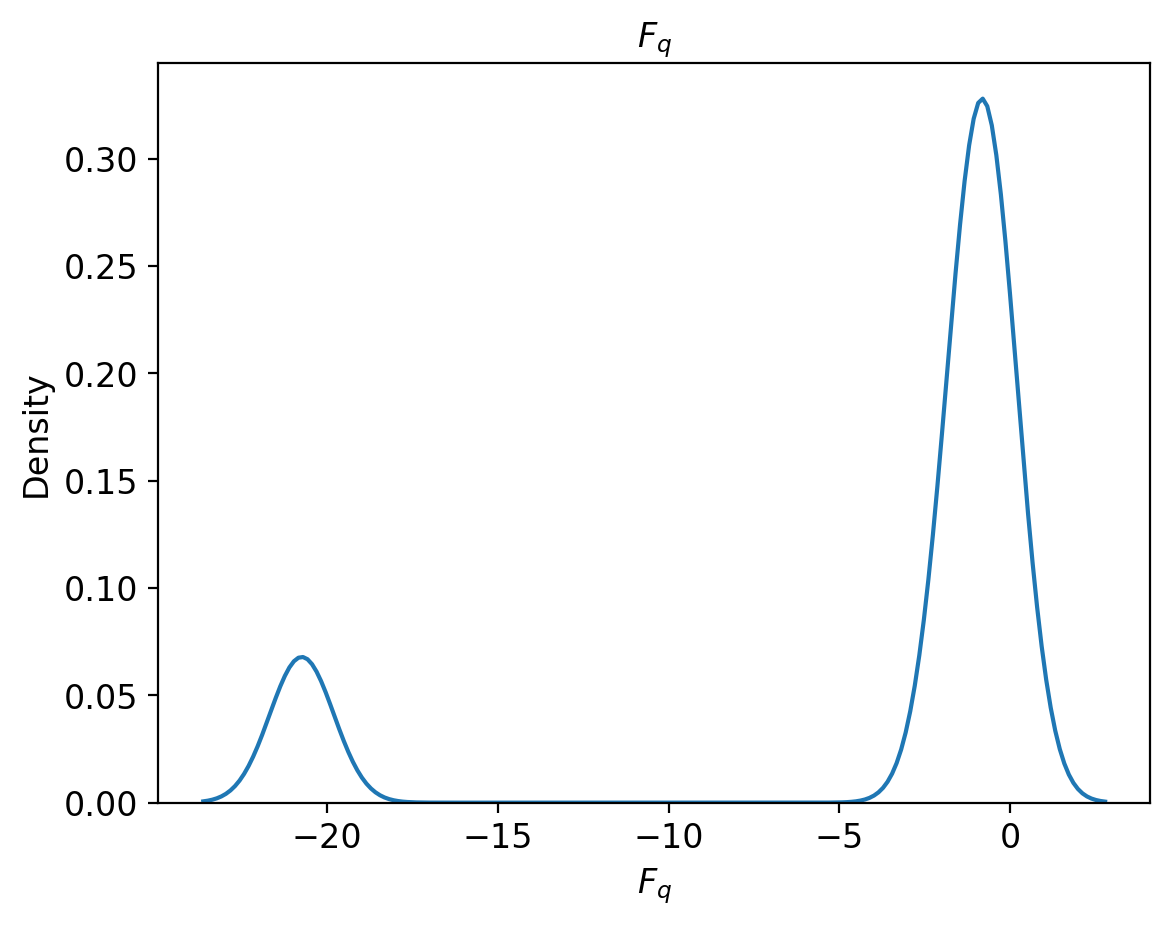

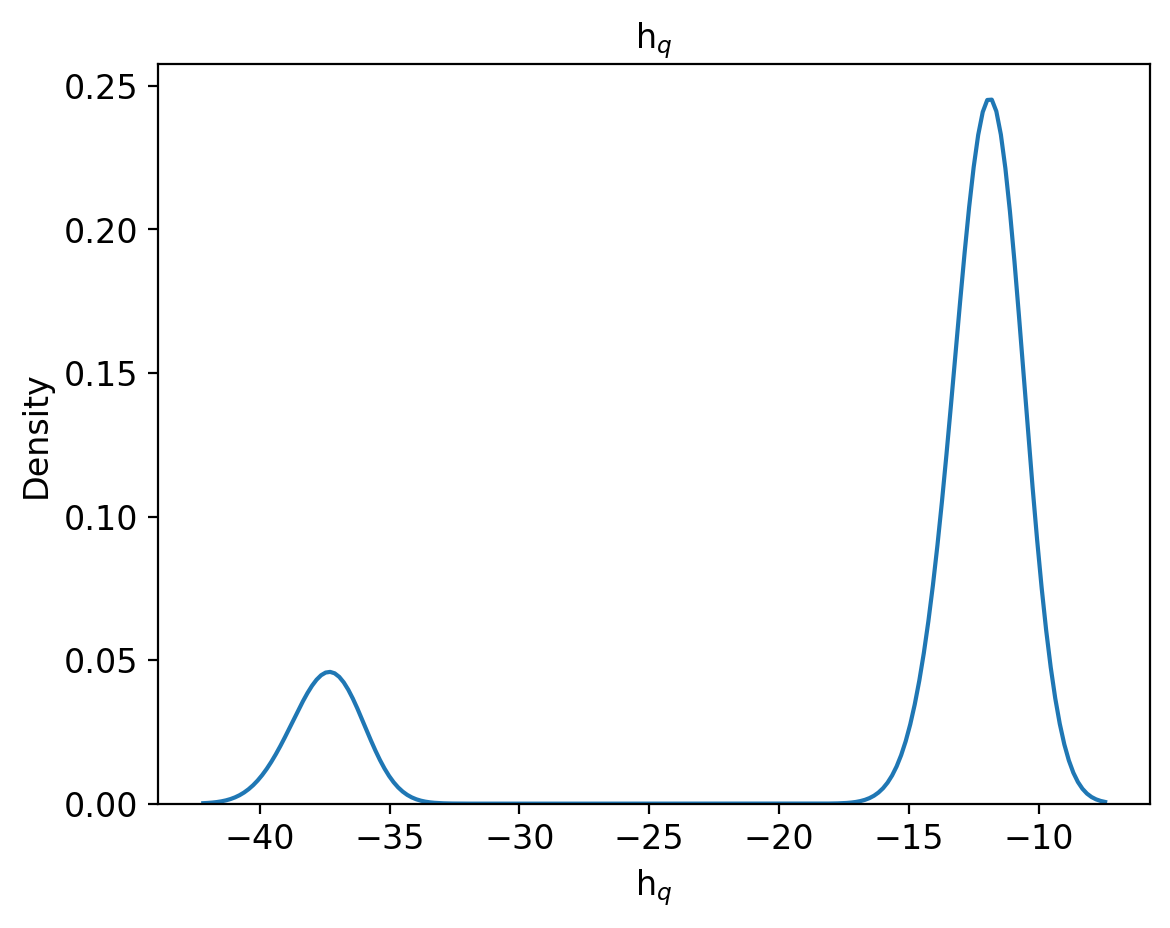

In [50]:
for f in dffeat.sort_values(by='shap').iloc[-10:]['feat']:
    try:
        sns.kdeplot(pd.concat([train_df,test_df])[f])
    except:
        print(f)
    plt.title(f)
    plt.show()

In [51]:
dffeat.sort_values(by='shap').iloc[-10:]['feat'].tolist()

['$(\\eta_{r})_{2}$',
 '$\\langle ss \\vert ss \\rangle$',
 '$\\langle qq \\vert qq \\rangle$',
 'h$_{qs}$',
 '(h$_{rs}$)$_{1}$',
 '$F_{q}^{\\text{SCF}}$',
 '$(F_{p}^{\\text{SCF}})_{3}$',
 '$\\eta_{s}$',
 '$F_{q}$',
 'h$_{q}$']

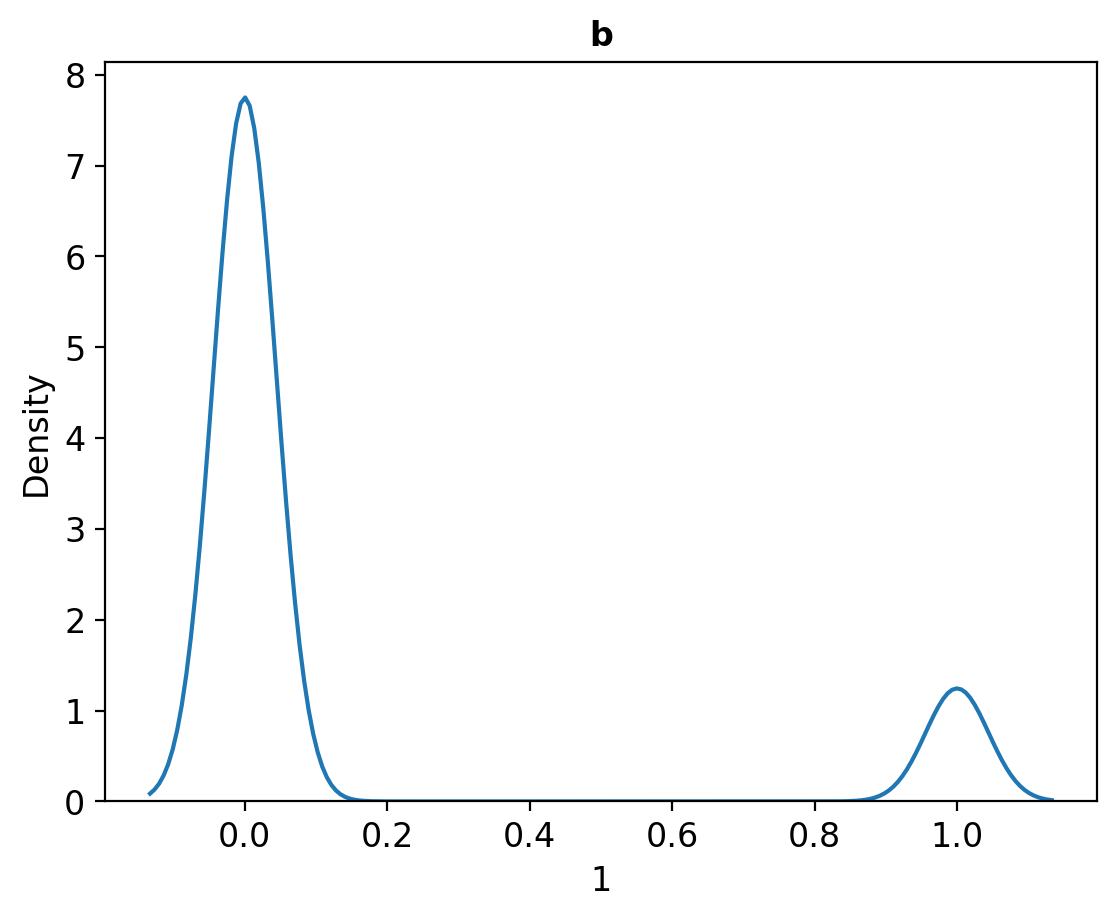

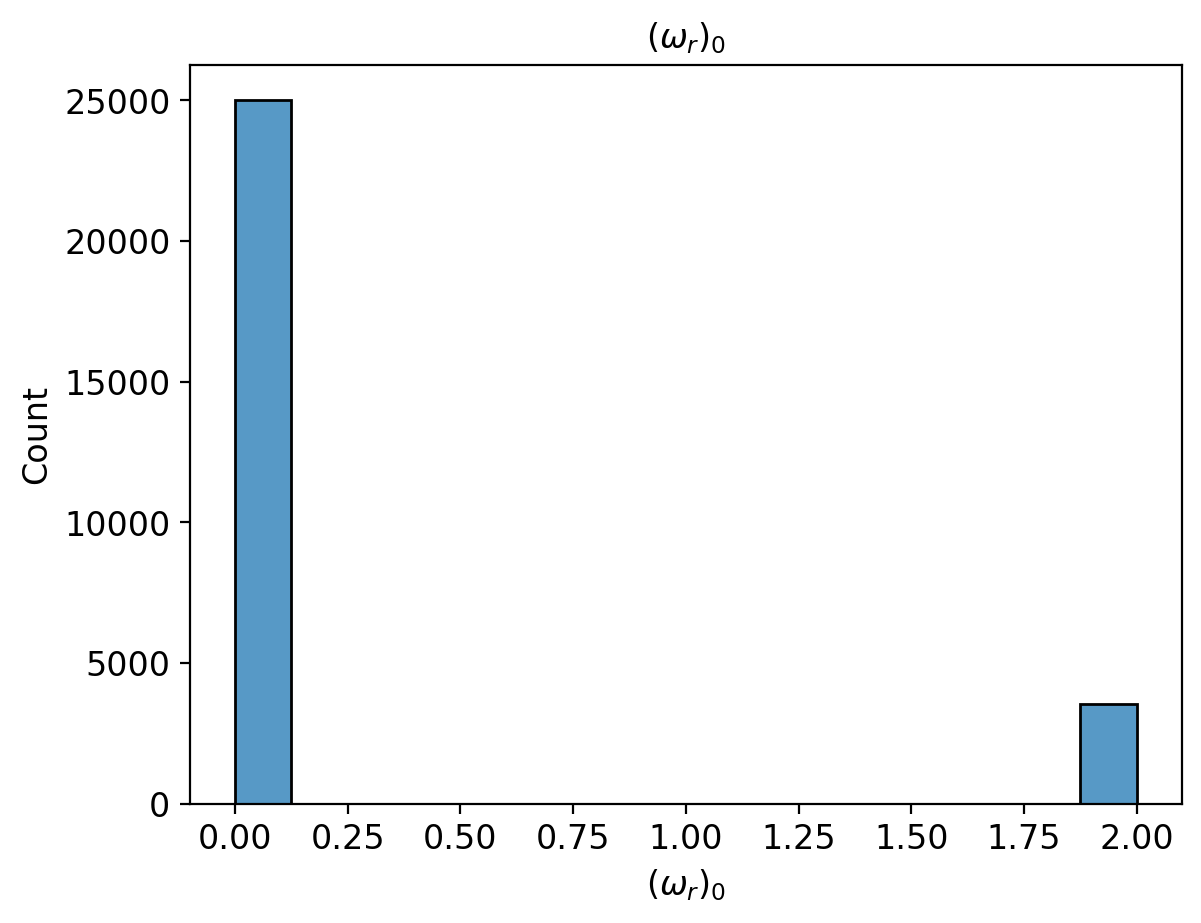

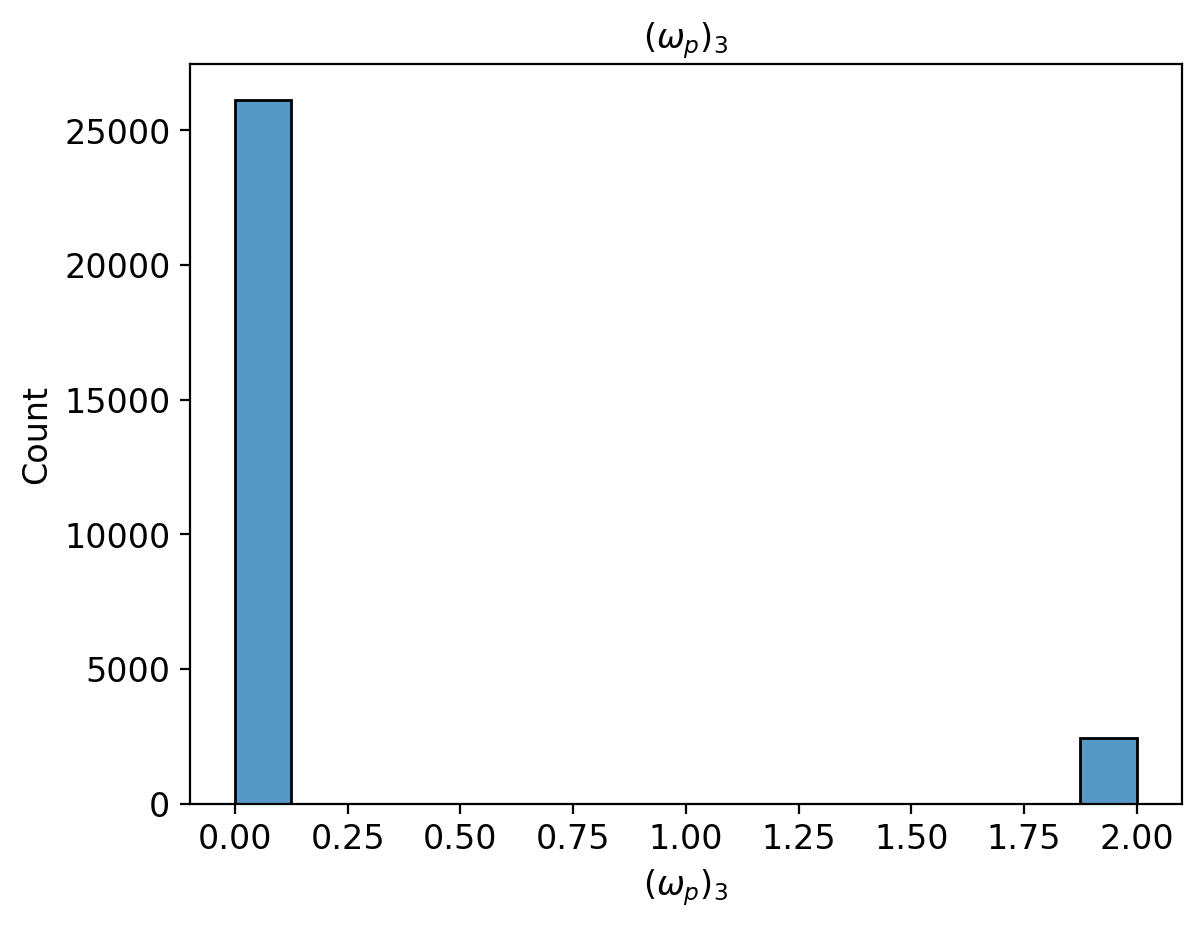

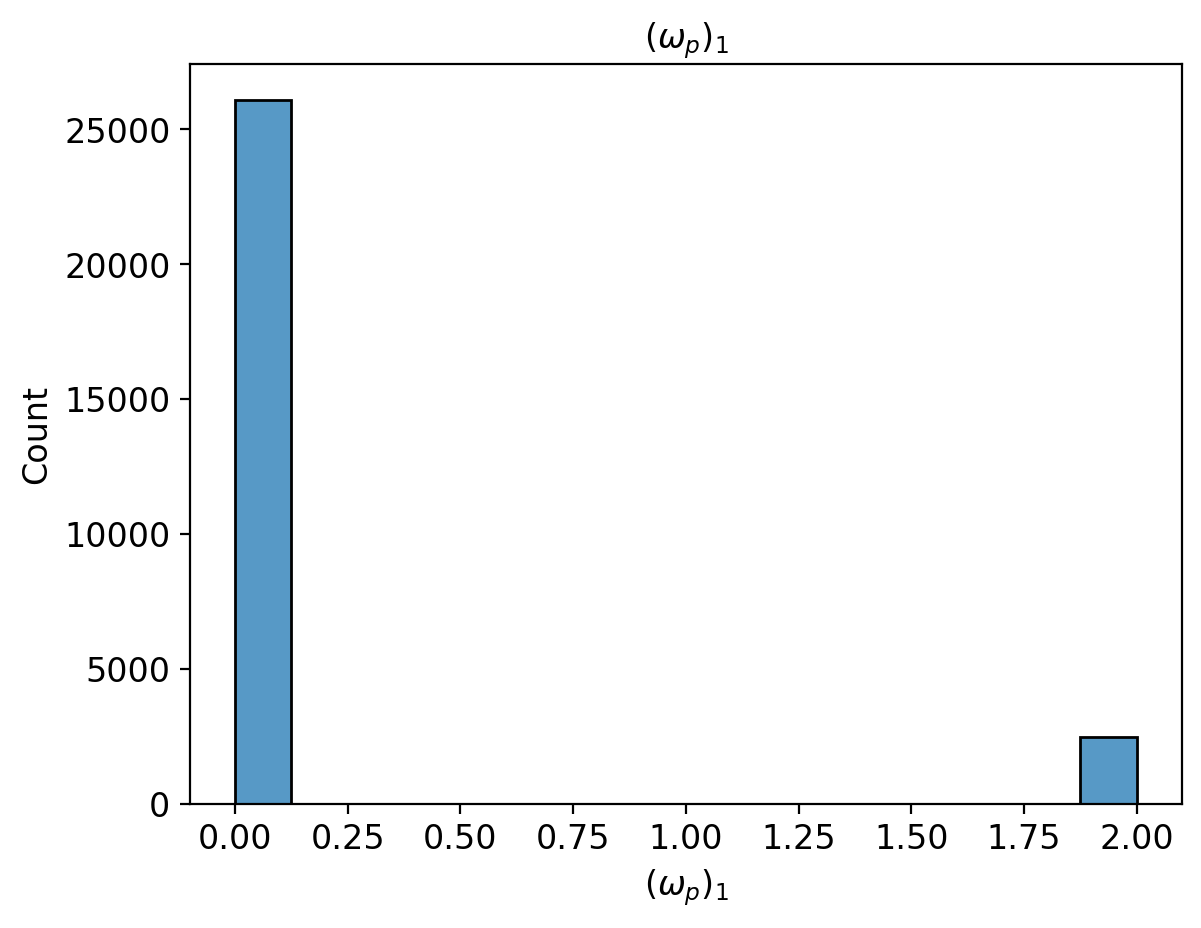

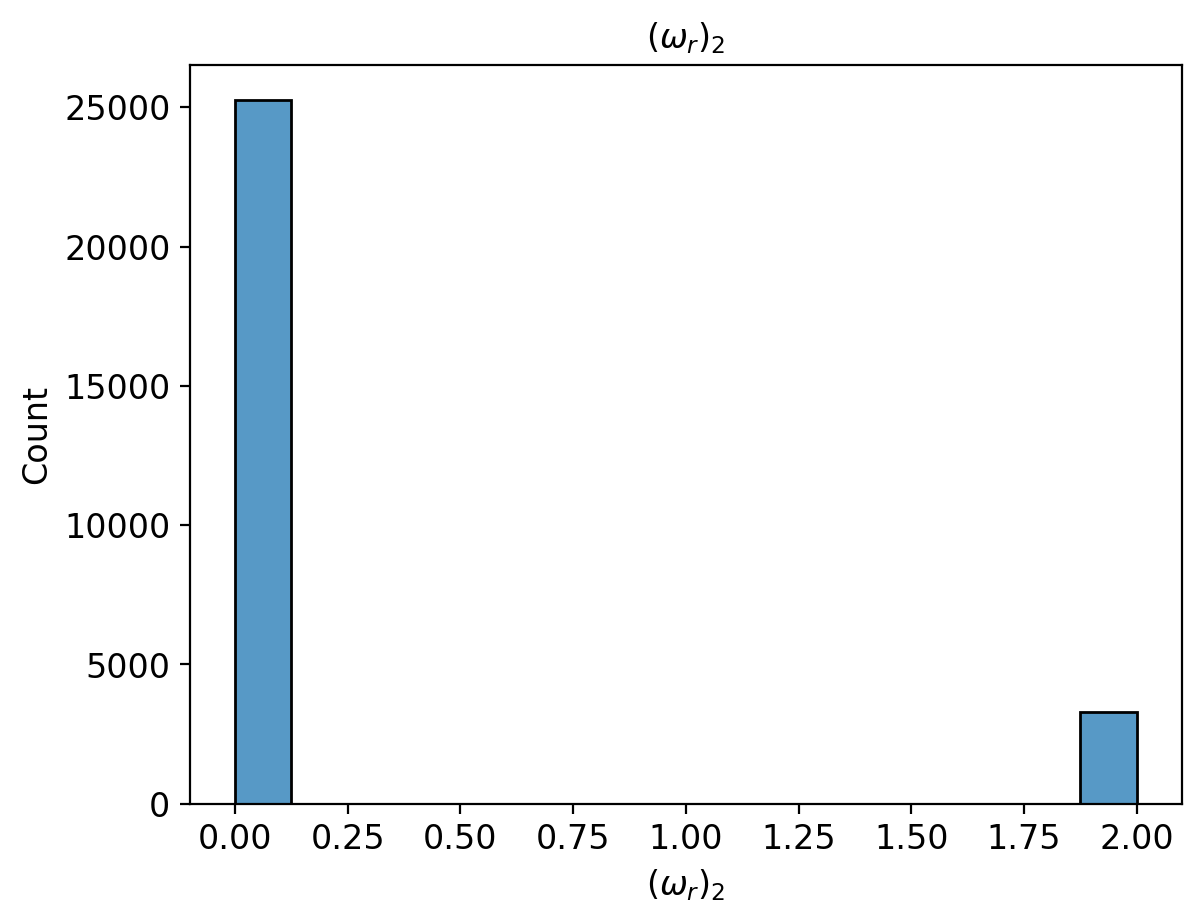

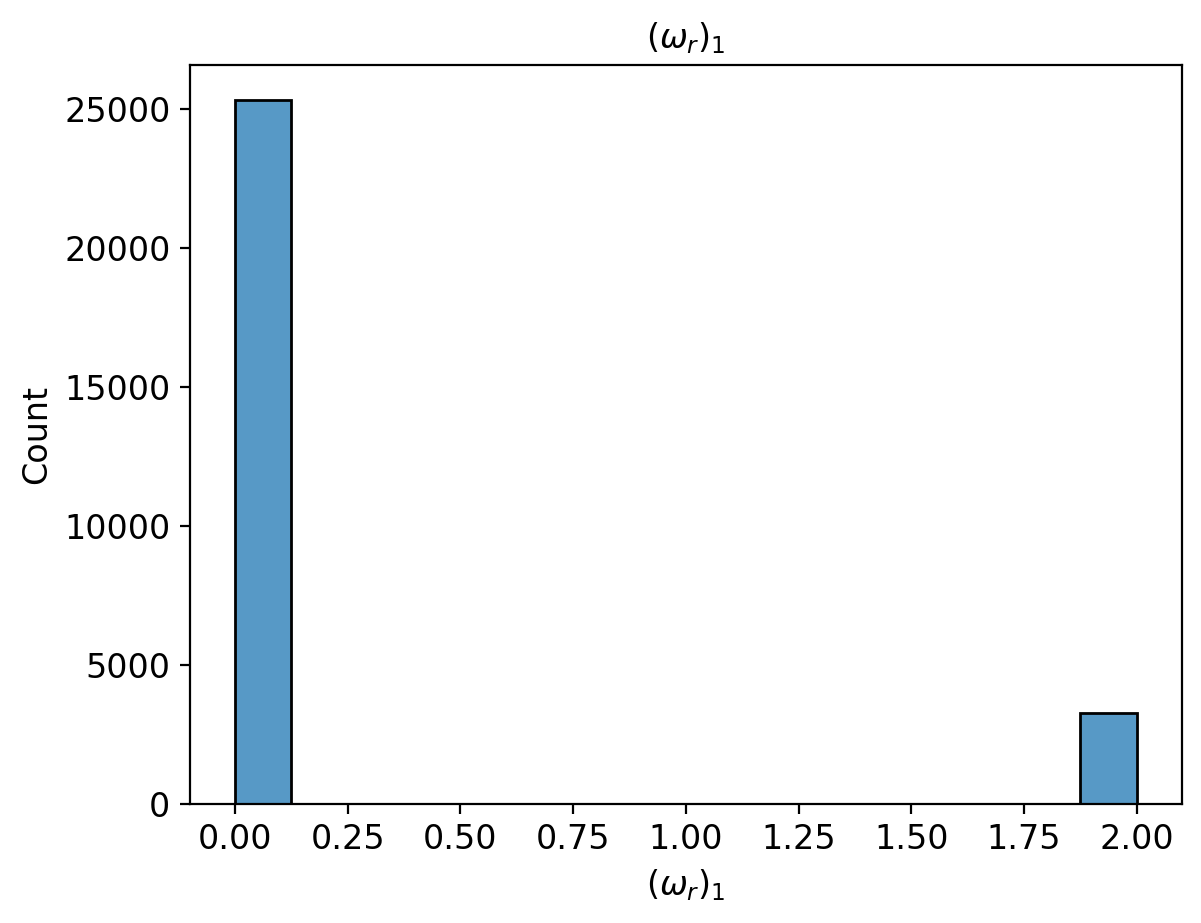

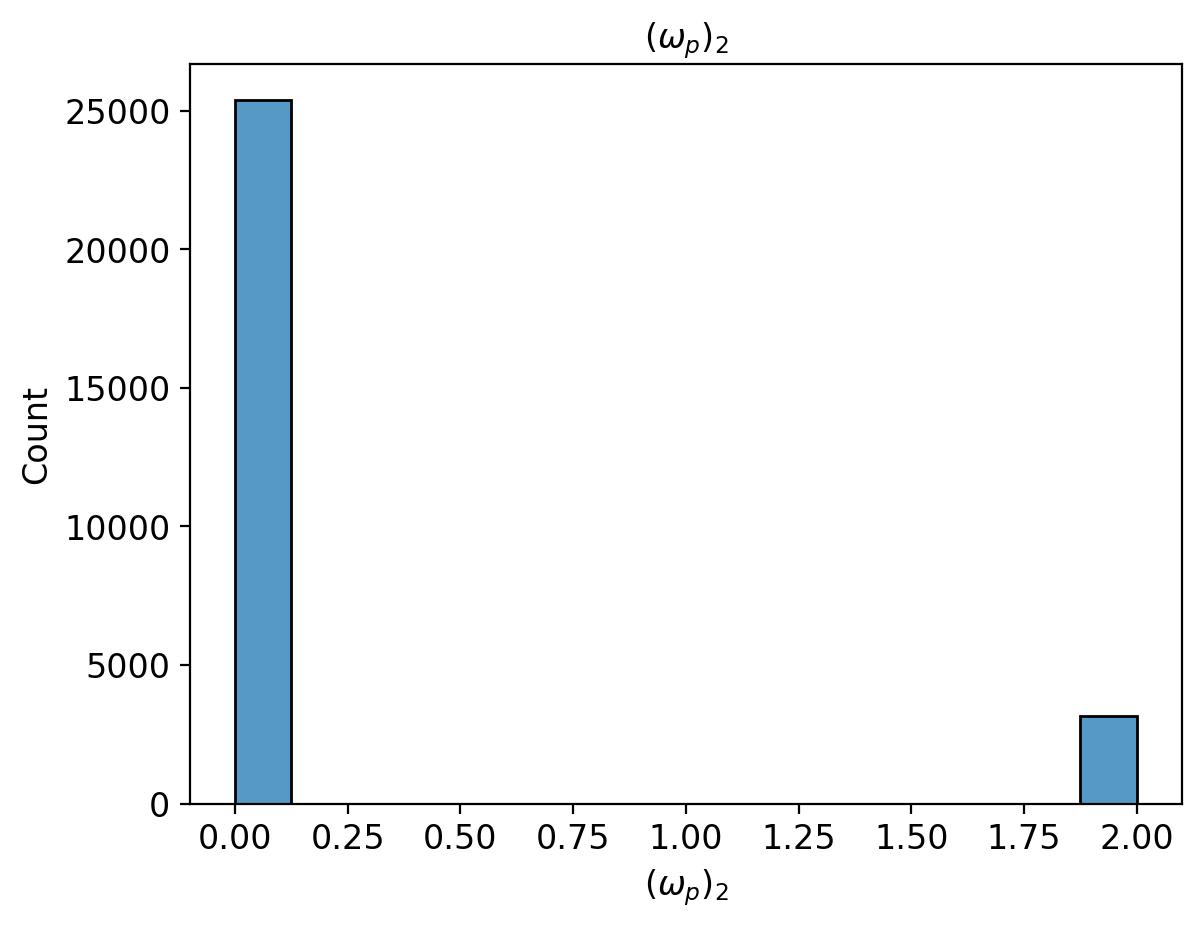

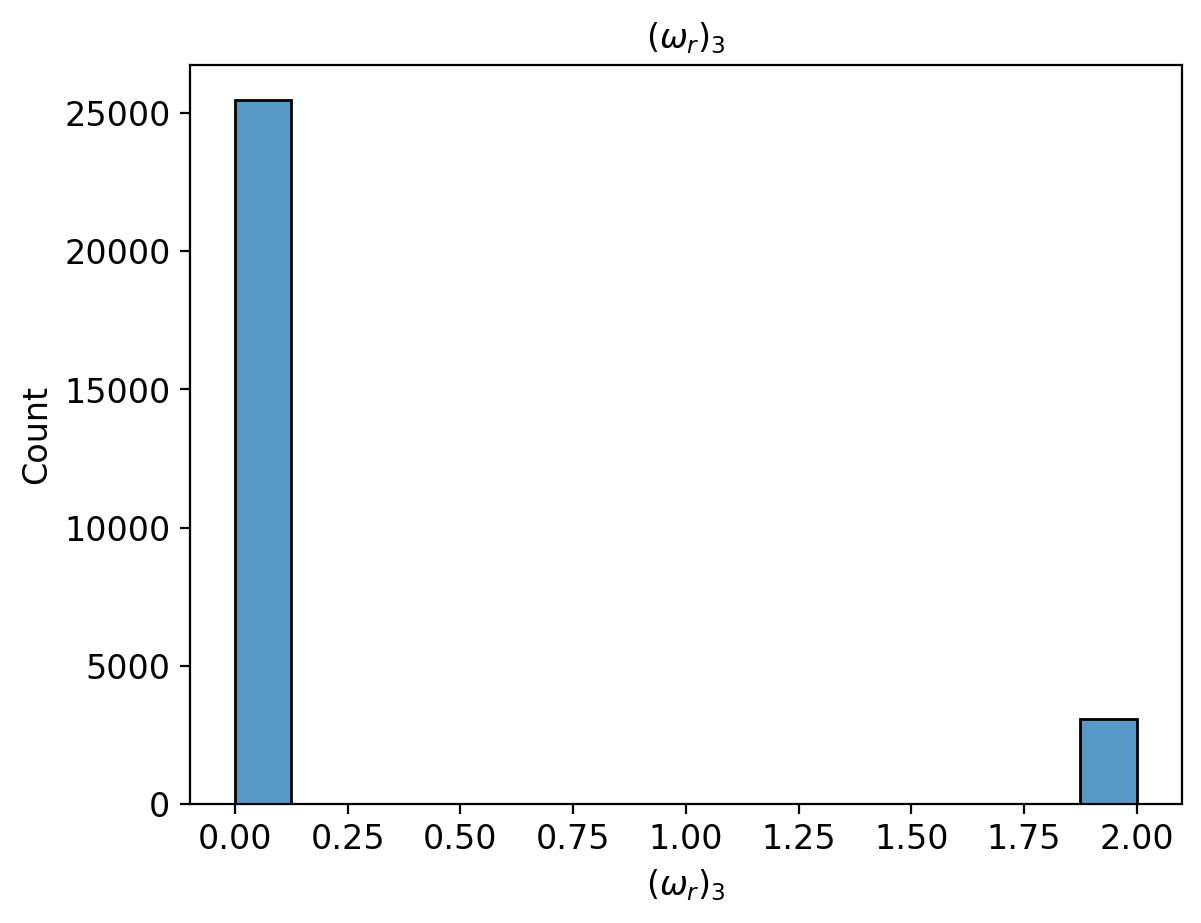

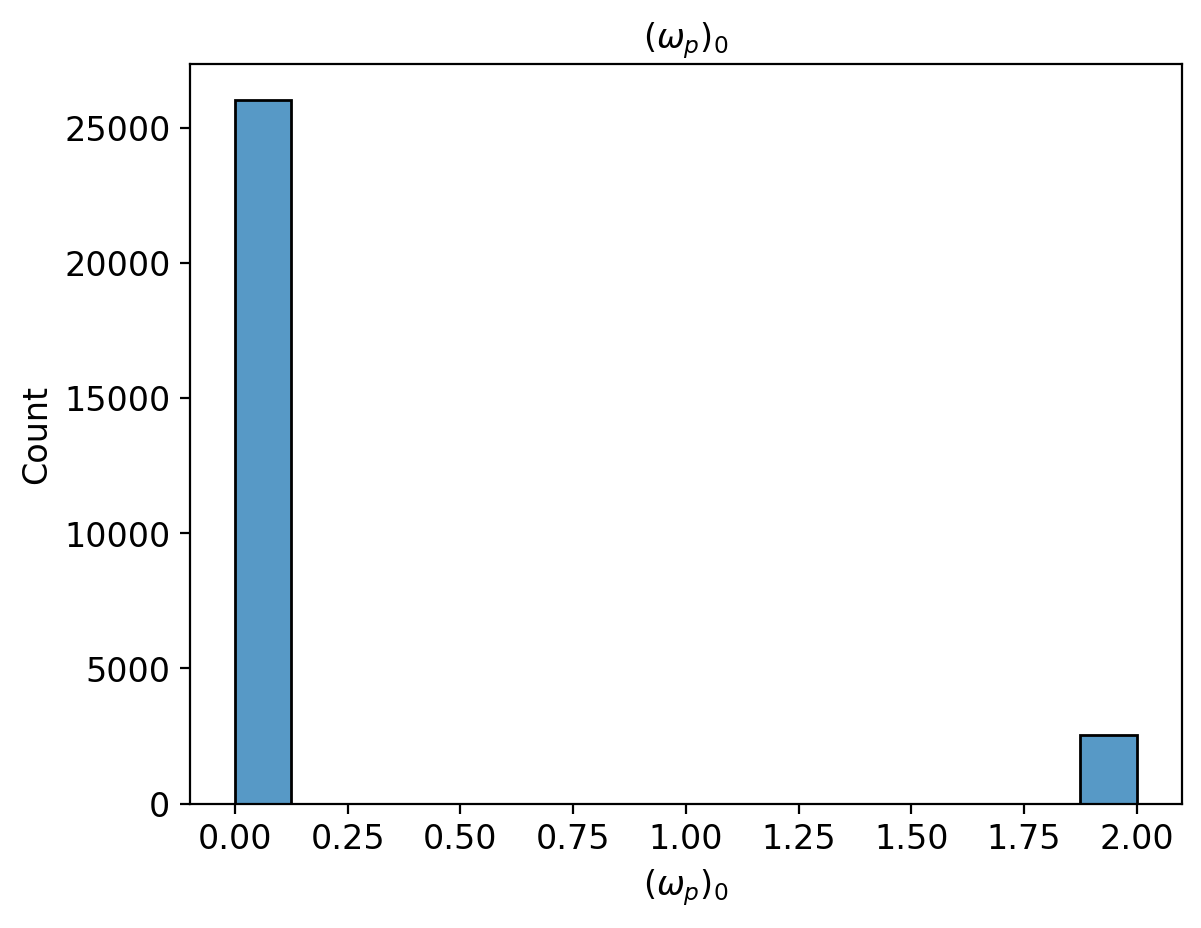

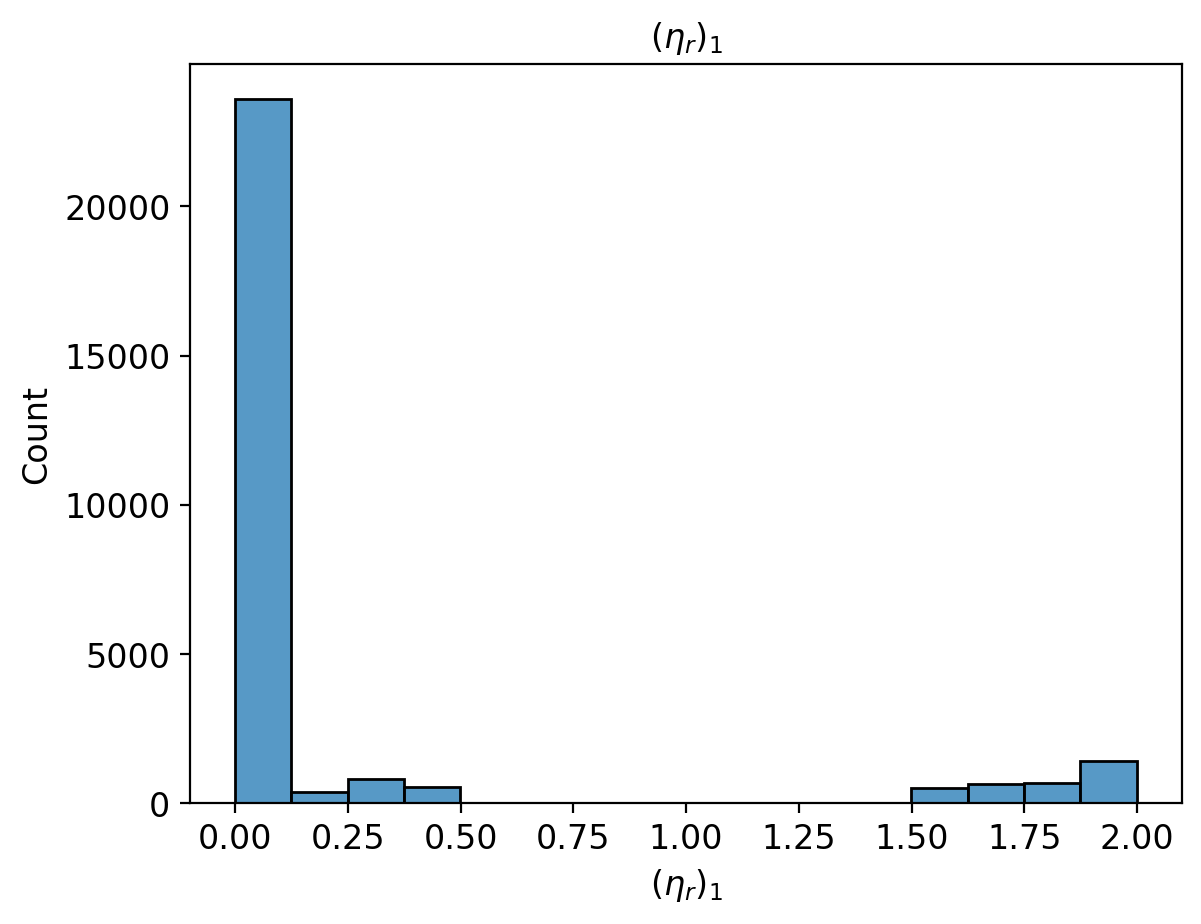

In [52]:
for f in dffeat.sort_values(by='shap').iloc[0:10]['feat']:
    try:
        # print(f,((pd.concat([train_df,test_df])[f]).value_counts()/len(pd.concat([train_df,test_df])[f])).round(2))
        sns.histplot(pd.concat([train_df,test_df])[f])
    except:
        if f=='$\mathbf{b}$':
            sns.kdeplot(pd.concat([train_df,test_df])['1'])
        else:
            sns.kdeplot(pd.concat([train_df,test_df])[fr"{f}"],color='r')
    plt.title(f)
    plt.show()
    # print()

In [53]:
r2_score(traincorrE2['E$_{\text{CASPT2}}^{\text{Calculated}}$'],traincorrE2['E$_{\text{CASPT2}}^{\text{Predicted}}$'])

0.9992270874500383

In [54]:
r2_score(testcorrE2['E$_{\text{CASPT2}}^{\text{Calculated}}$'],testcorrE2['E$_{\text{CASPT2}}^{\text{Predicted}}$'])

0.9983132282065185

In [55]:
mean_absolute_error(traincorrE2['E$_{\text{CASPT2}}^{\text{Calculated}}$'],traincorrE2['E$_{\text{CASPT2}}^{\text{Predicted}}$'])*1e3

np.float64(1.1187288434583493)

In [56]:
mean_absolute_error(testcorrE2['E$_{\text{CASPT2}}^{\text{Calculated}}$'],testcorrE2['E$_{\text{CASPT2}}^{\text{Predicted}}$'])*1e3

np.float64(1.5144674645959582)